In [1]:
%matplotlib inline
%reload_ext autoreload
#%autoreload 2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
import math
import cycler
import scipy.integrate
import scipy as sp
import time
import scipy.signal
from cycler import cycler
import cmasher as cmr
import matplotlib as mpl
import matplotlib.ticker as ticker
#plt.style.use("jcap")
import dill
#plt.style.use(["default", "plotz.jcap"])

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' 

In [2]:

import classy
print(classy.__file__)


/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/classy-3.2.3-py3.7-linux-x86_64.egg/classy.cpython-37m-x86_64-linux-gnu.so


In [3]:
planck18_best_fit = {'100*theta_s': 1.04109, 'omega_b':0.02233 , 'omega_cdm': 0.1198, 'tau_reio':0.0540, 'A_s':2.09681e-9, 'n_s': 0.9652 }
output_settings = {'output':'tCl,pCl,lCl,mPk,dTk,vTk','lensing':'yes','P_k_max_1/Mpc':3.0, 'k_output_values' :'0.008, 0.004, 0.001, 0.01, 0.1, 1.', 'z_pk': '1000.0, 100.0, 10.0, 0.0'}
gbh_tables = {'gbh_w_table': '/rds/general/user/an421/home/CLASS_GBH/class/table_omegas.txt',
              'gbh_rho_table': '/rds/general/user/an421/home/CLASS_GBH/class/table_rho.txt',
             'has_gbh_pt': 1, 'gauge': 'Newtonian', 'n_max_gbh': 30 ,'ubound_x_gbh': 15, 
              'ncdm_fluid_approximation':3, #turn off ncdm fluid approximation
              #'ncdm_fluid_trigger_tau_over_tau_k':100.,
              'GBH_fluid_approx_method':3 
             }

M_nu = 0.03 #set mass of gbh and ncdm species

In [4]:
#ncdm with CLASS FA
ncdmFA_CLASS = Class()
ncdmFA_CLASS.set(planck18_best_fit)
ncdmFA_CLASS.set(gbh_tables)
ncdmFA_CLASS.set(output_settings)
ncdmFA_CLASS.set({'N_ur': 0, 'N_gbh': 0, 'has_gbh_pt': 0})
ncdmFA_CLASS.set({'N_ncdm': 1,  'm_ncdm': rf'{M_nu}'})
ncdmFA_CLASS.set({'ncdm_fluid_approximation': 2})

ncdmFA_CLASS.compute()

In [5]:
#ncdm with Caio's FA
ncdmFA_caio = Class()
ncdmFA_caio.set(planck18_best_fit)
ncdmFA_caio.set(gbh_tables)
ncdmFA_caio.set(output_settings)
ncdmFA_caio.set({'N_ur': 0, 'N_gbh': 0, 'has_gbh_pt': 0})
ncdmFA_caio.set({'N_ncdm': 1,  'm_ncdm': rf'{M_nu}'})
ncdmFA_caio.set({'ncdm_fluid_approximation': 4})

ncdmFA_caio.compute()

In [6]:
#ncdm high precision
ncdm_noFA = Class()
ncdm_noFA.set(planck18_best_fit)
ncdm_noFA.set(gbh_tables)
ncdm_noFA.set(output_settings)
ncdm_noFA.set({'N_ur': 0, 'N_gbh': 0, 'has_gbh_pt': 0})
ncdm_noFA.set({'N_ncdm': 1,  'm_ncdm': rf'{M_nu}'})
ncdm_noFA.set({'ncdm_fluid_approximation': 3, 'Quadrature strategy': 3, 'Maximum_q': 15, 'Number of momentum bins': 30, 'l_max_ncdm': 30})

ncdm_noFA.compute()

In [7]:
gbh_FA_CLASS = Class()
gbh_FA_CLASS.set(planck18_best_fit)
gbh_FA_CLASS.set(gbh_tables)
gbh_FA_CLASS.set(output_settings)
gbh_FA_CLASS.set({'N_ur': 0, 'N_ncdm': 0})
gbh_FA_CLASS.set({'N_gbh': 1, 'M_gbh': M_nu})
gbh_FA_CLASS.set({'GBH_fluid_approx_method': 2})
gbh_FA_CLASS.compute()

In [8]:
gbh_FA_caio = Class()
gbh_FA_caio.set(planck18_best_fit)
gbh_FA_caio.set(gbh_tables)
gbh_FA_caio.set(output_settings)
gbh_FA_caio.set({'N_ur': 0, 'N_ncdm': 0})
gbh_FA_caio.set({'N_gbh': 1, 'M_gbh': M_nu})
gbh_FA_caio.set({'GBH_fluid_approx_method': 3})
gbh_FA_caio.compute()

In [9]:
ncdmFA_CLASS.Neff()

1.0131982214534323

In [10]:
gbh_FA_CLASS.Neff()

1.0132016274835076

# Background

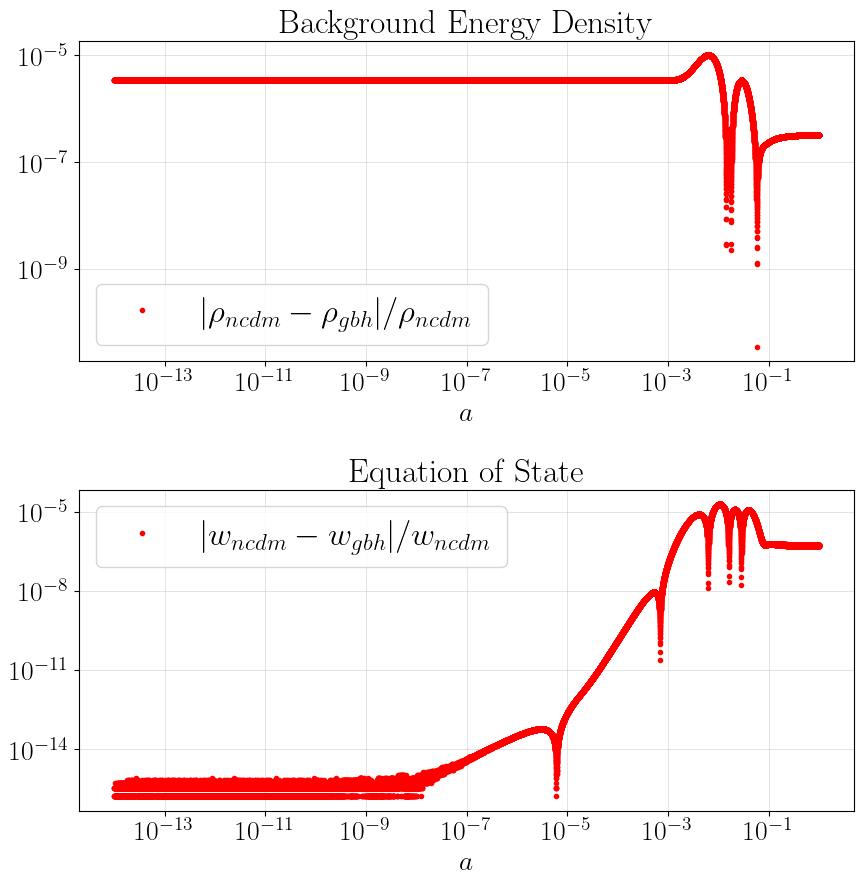

In [19]:
z = ncdmFA_CLASS.get_background()['z']
a = 1/(1+z)
# use interpolators in case the ouput values of scale factor vary between the two cosmologies (not necessary but more robust)
rho_ncdm = sp.interpolate.interp1d(1/(1+ncdmFA_CLASS.get_background()['z']), ncdmFA_CLASS.get_background()['(.)rho_ncdm[0]'])(a)
rho_gbh = 3*sp.interpolate.interp1d(1/(1+gbh_FA_CLASS.get_background()['z']), gbh_FA_CLASS.get_background()['(.)P_gbh_[0]'])(a)

P_ncdm = sp.interpolate.interp1d(1/(1+ncdmFA_CLASS.get_background()['z']), ncdmFA_CLASS.get_background()['(.)p_ncdm[0]'])(a) 
P_gbh = sp.interpolate.interp1d(1/(1+gbh_FA_CLASS.get_background()['z']), gbh_FA_CLASS.get_background()['(.)P_gbh_[1]'])(a) 
w_ncdm = P_ncdm/rho_ncdm
w_gbh=P_gbh/rho_gbh

fig, axes = plt.subplots(2,1, figsize = (10,10), gridspec_kw={'hspace': 0.4})
axes[0].plot(a, np.abs(rho_ncdm-rho_gbh)/rho_ncdm, 'r.', label = r'$| \rho_{ncdm}- \rho_{gbh}| / \rho_{ncdm}$')
axes[1].plot(a, np.abs(w_ncdm-w_gbh)/w_ncdm, 'r.', label = r'$| w_{ncdm}- w_{gbh}| / w_{ncdm}$')

axes[0].set_title('Background Energy Density')
axes[1].set_title('Equation of State')
for ax in axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('$a$')
    
    ax.legend(fontsize='large')
    ax.grid(which="both",alpha = 0.5, linewidth=0.5)

# Perturbations
get_perturbations() returns a list of dicts for each k_output_values specified. let's plot the perturbations as well as the fractional difference in order

/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.


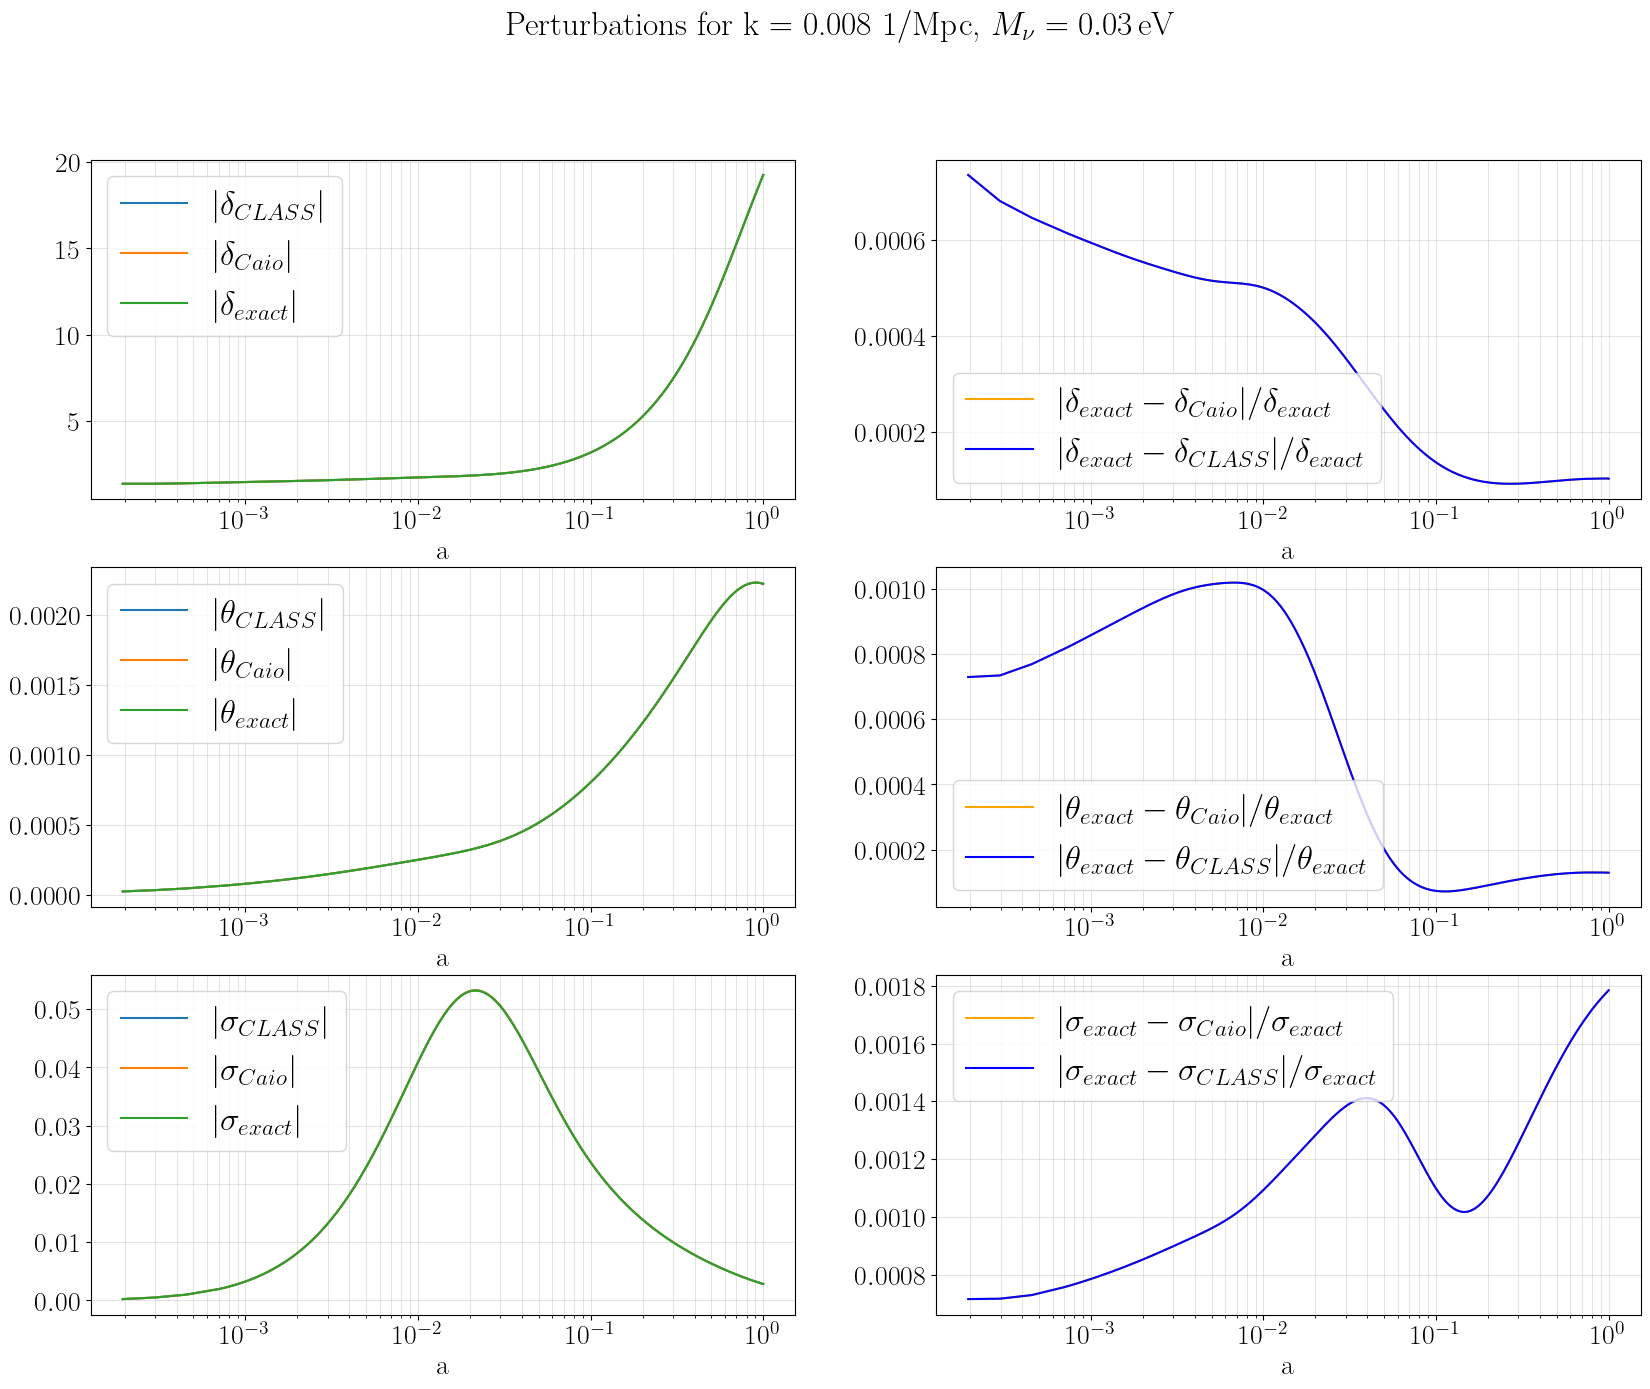

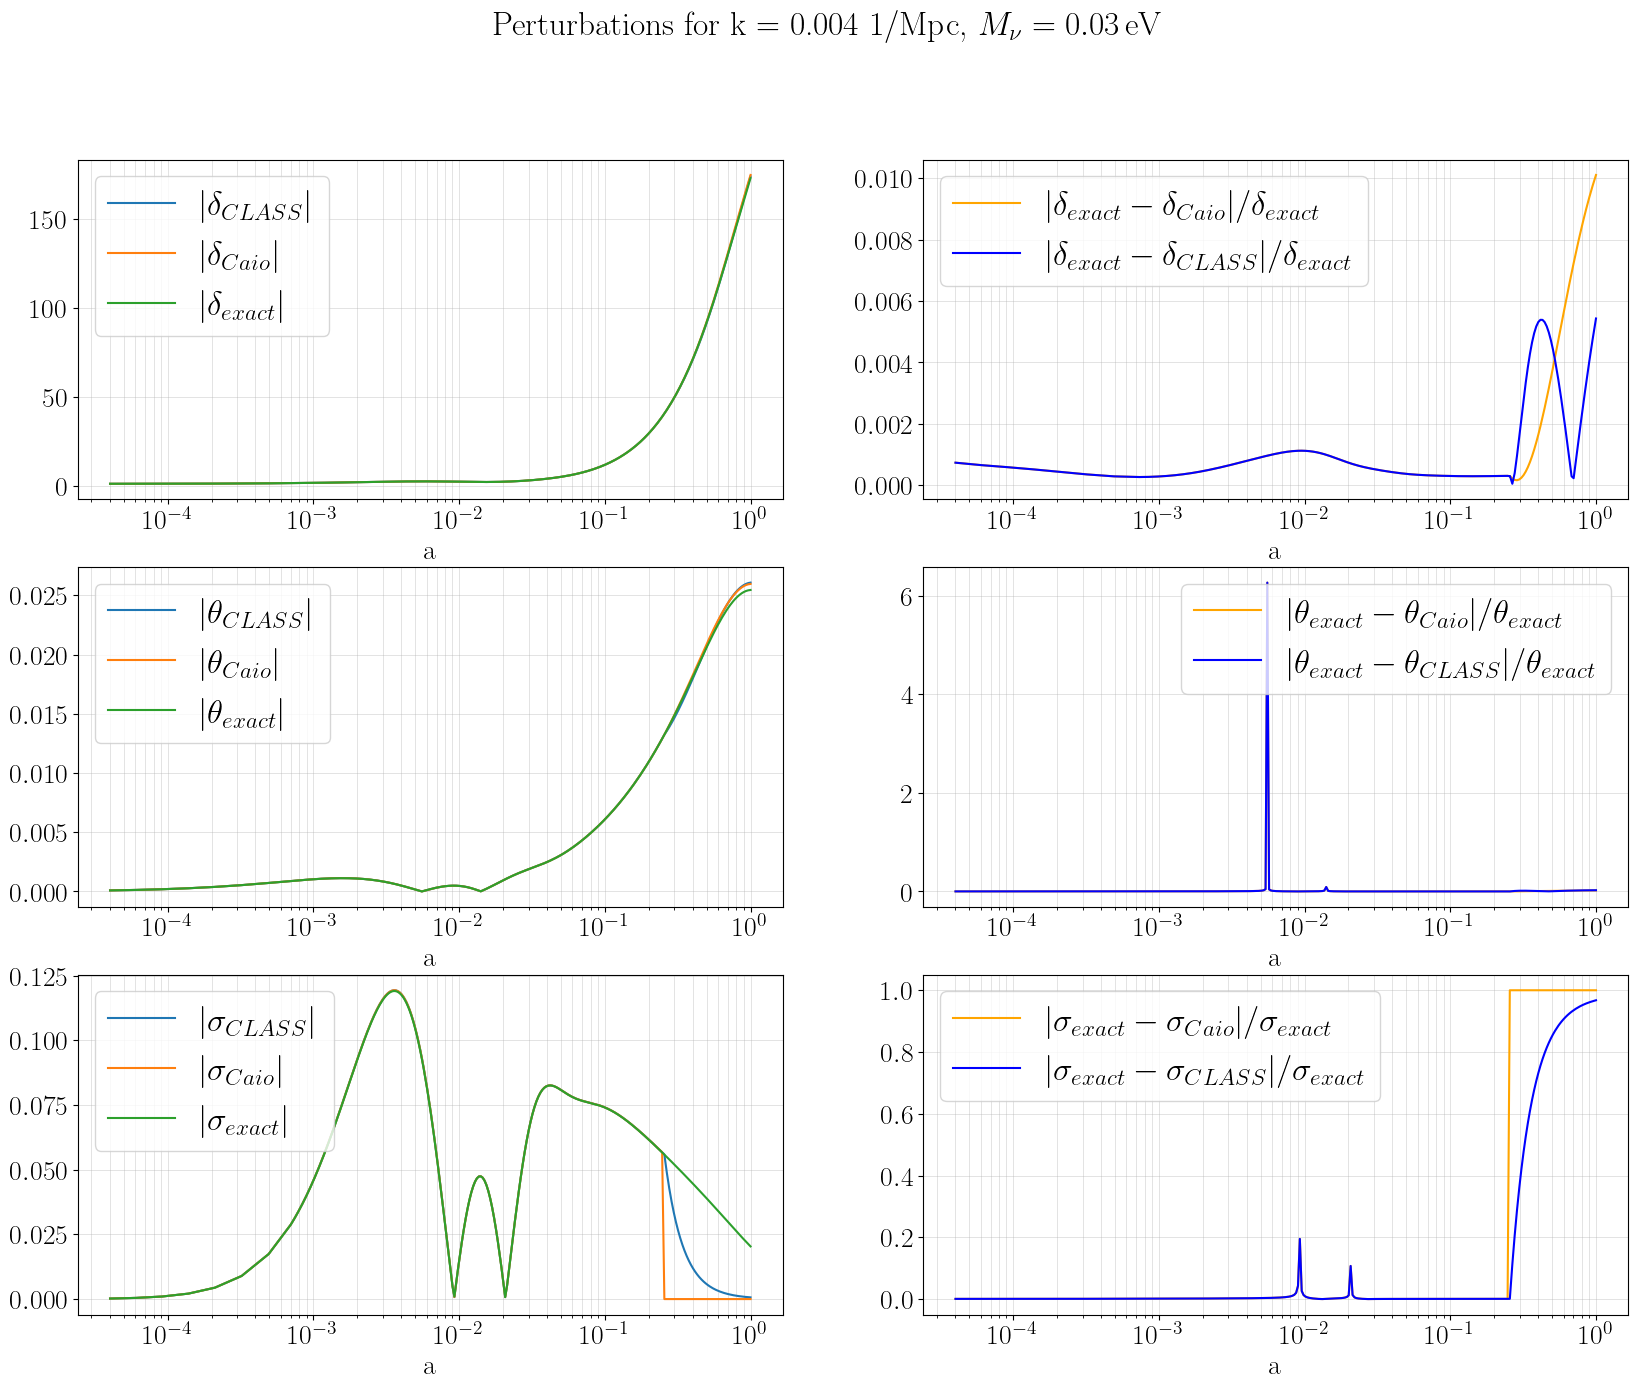

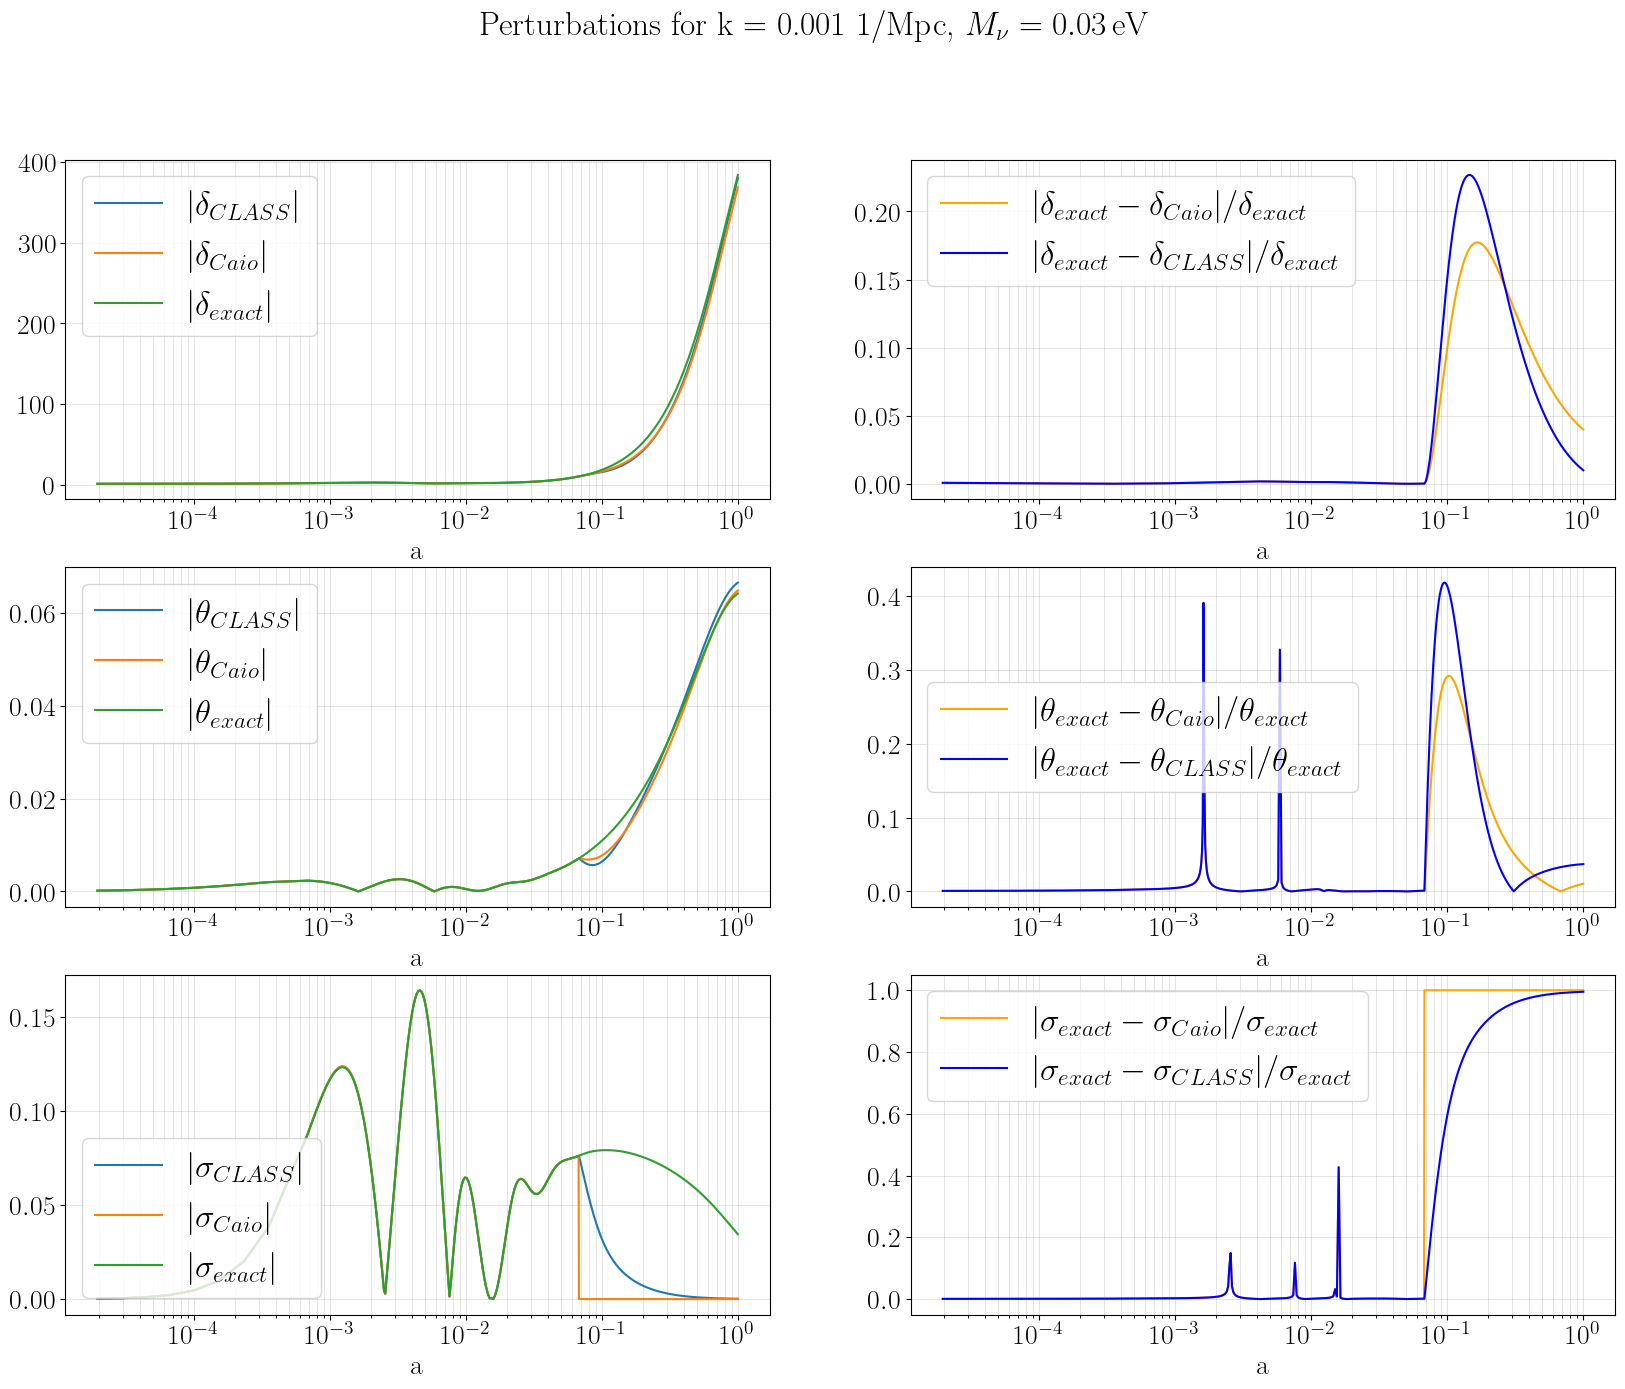

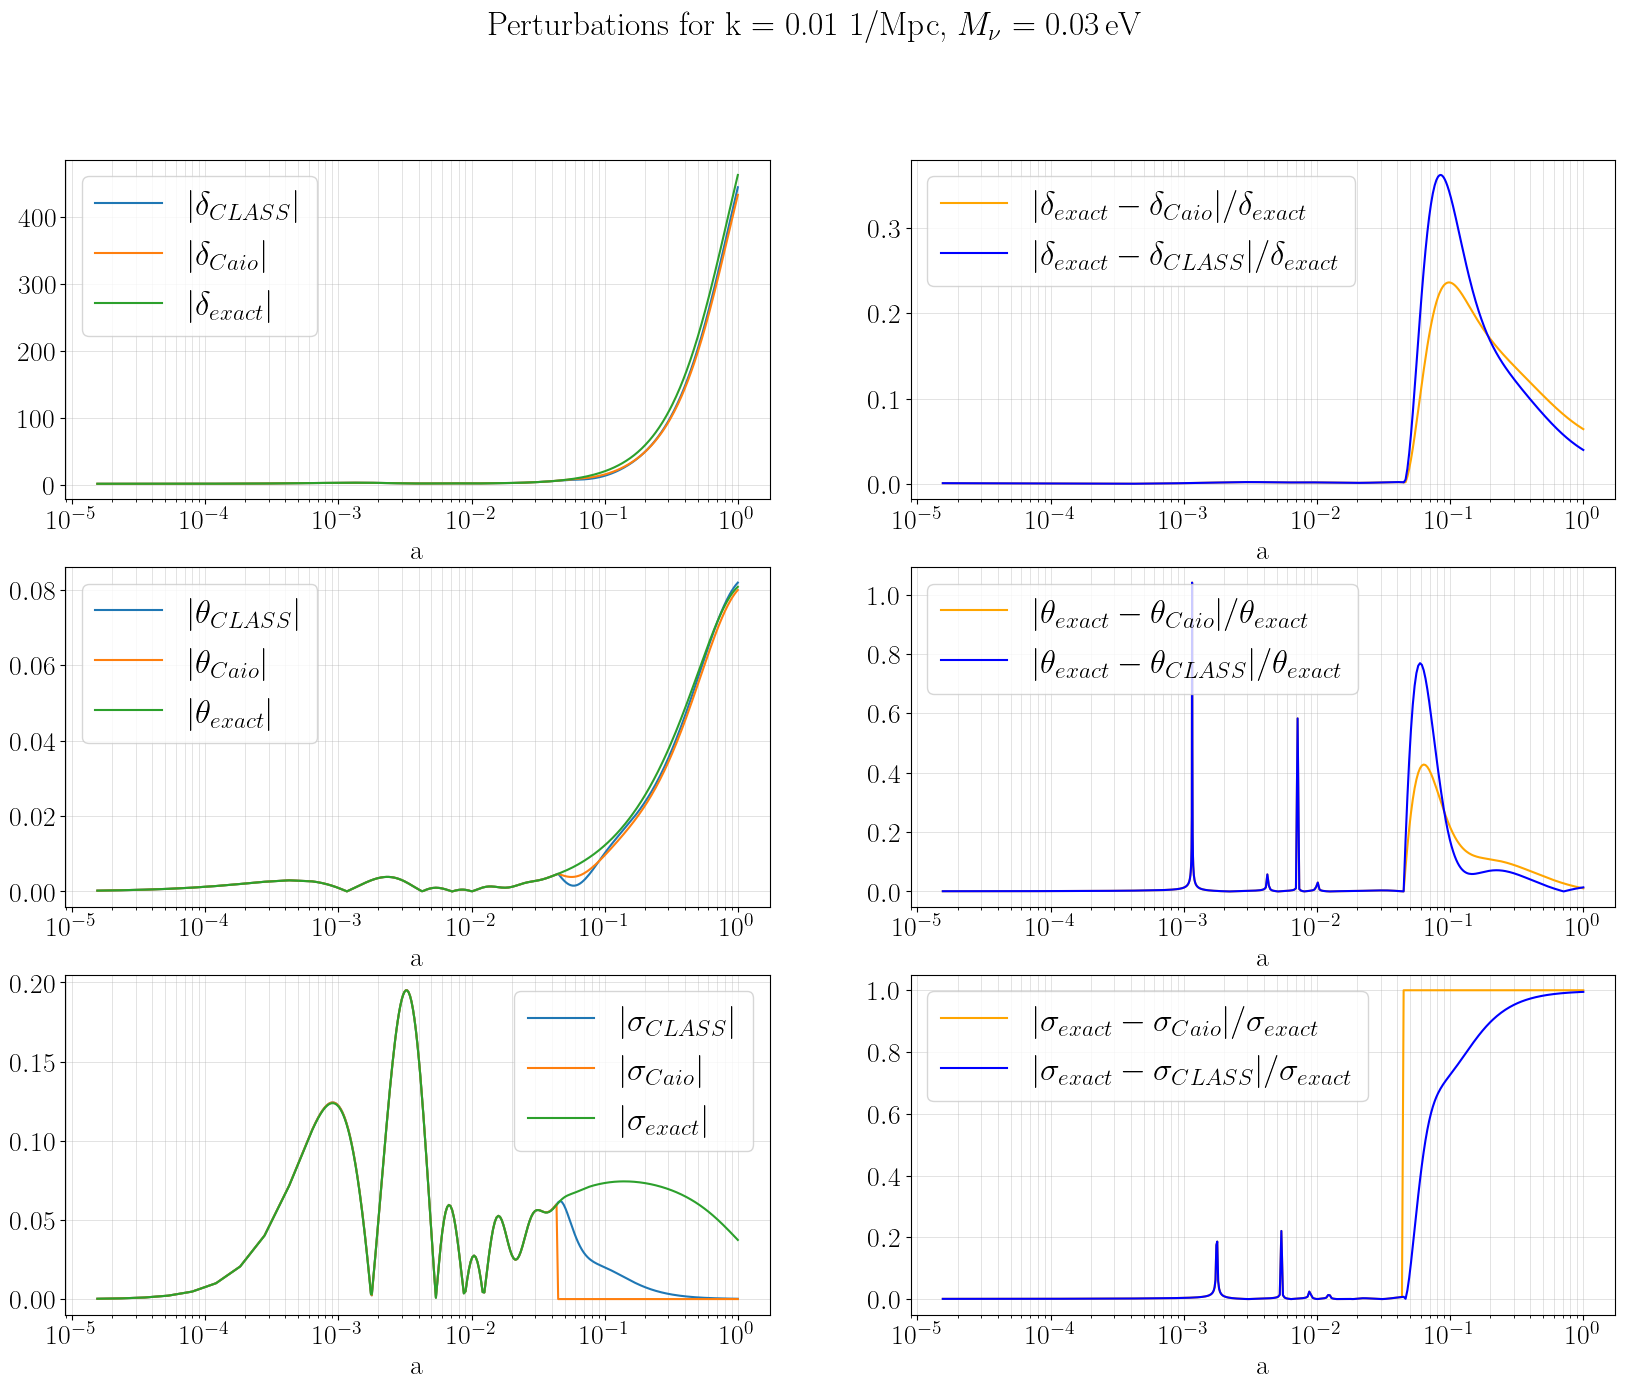

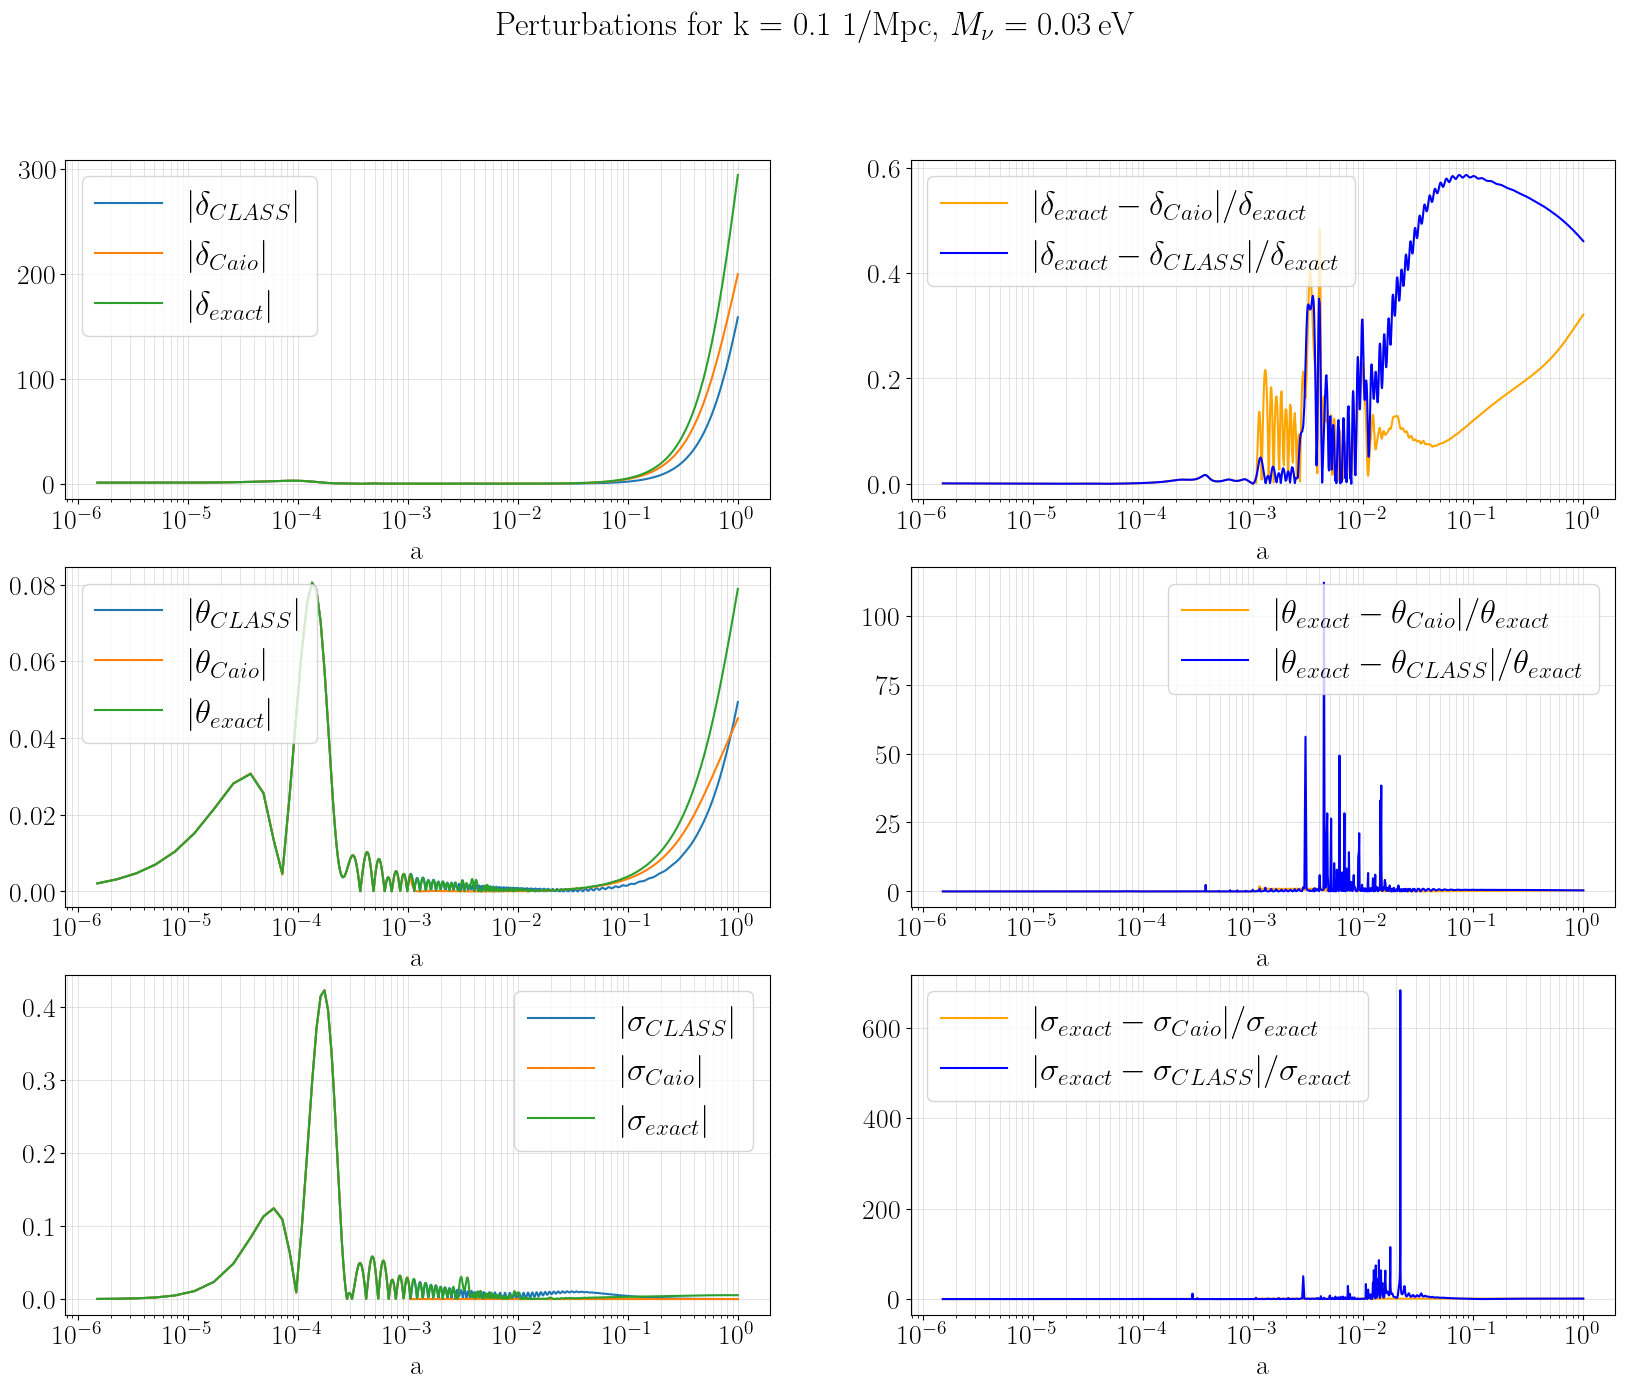

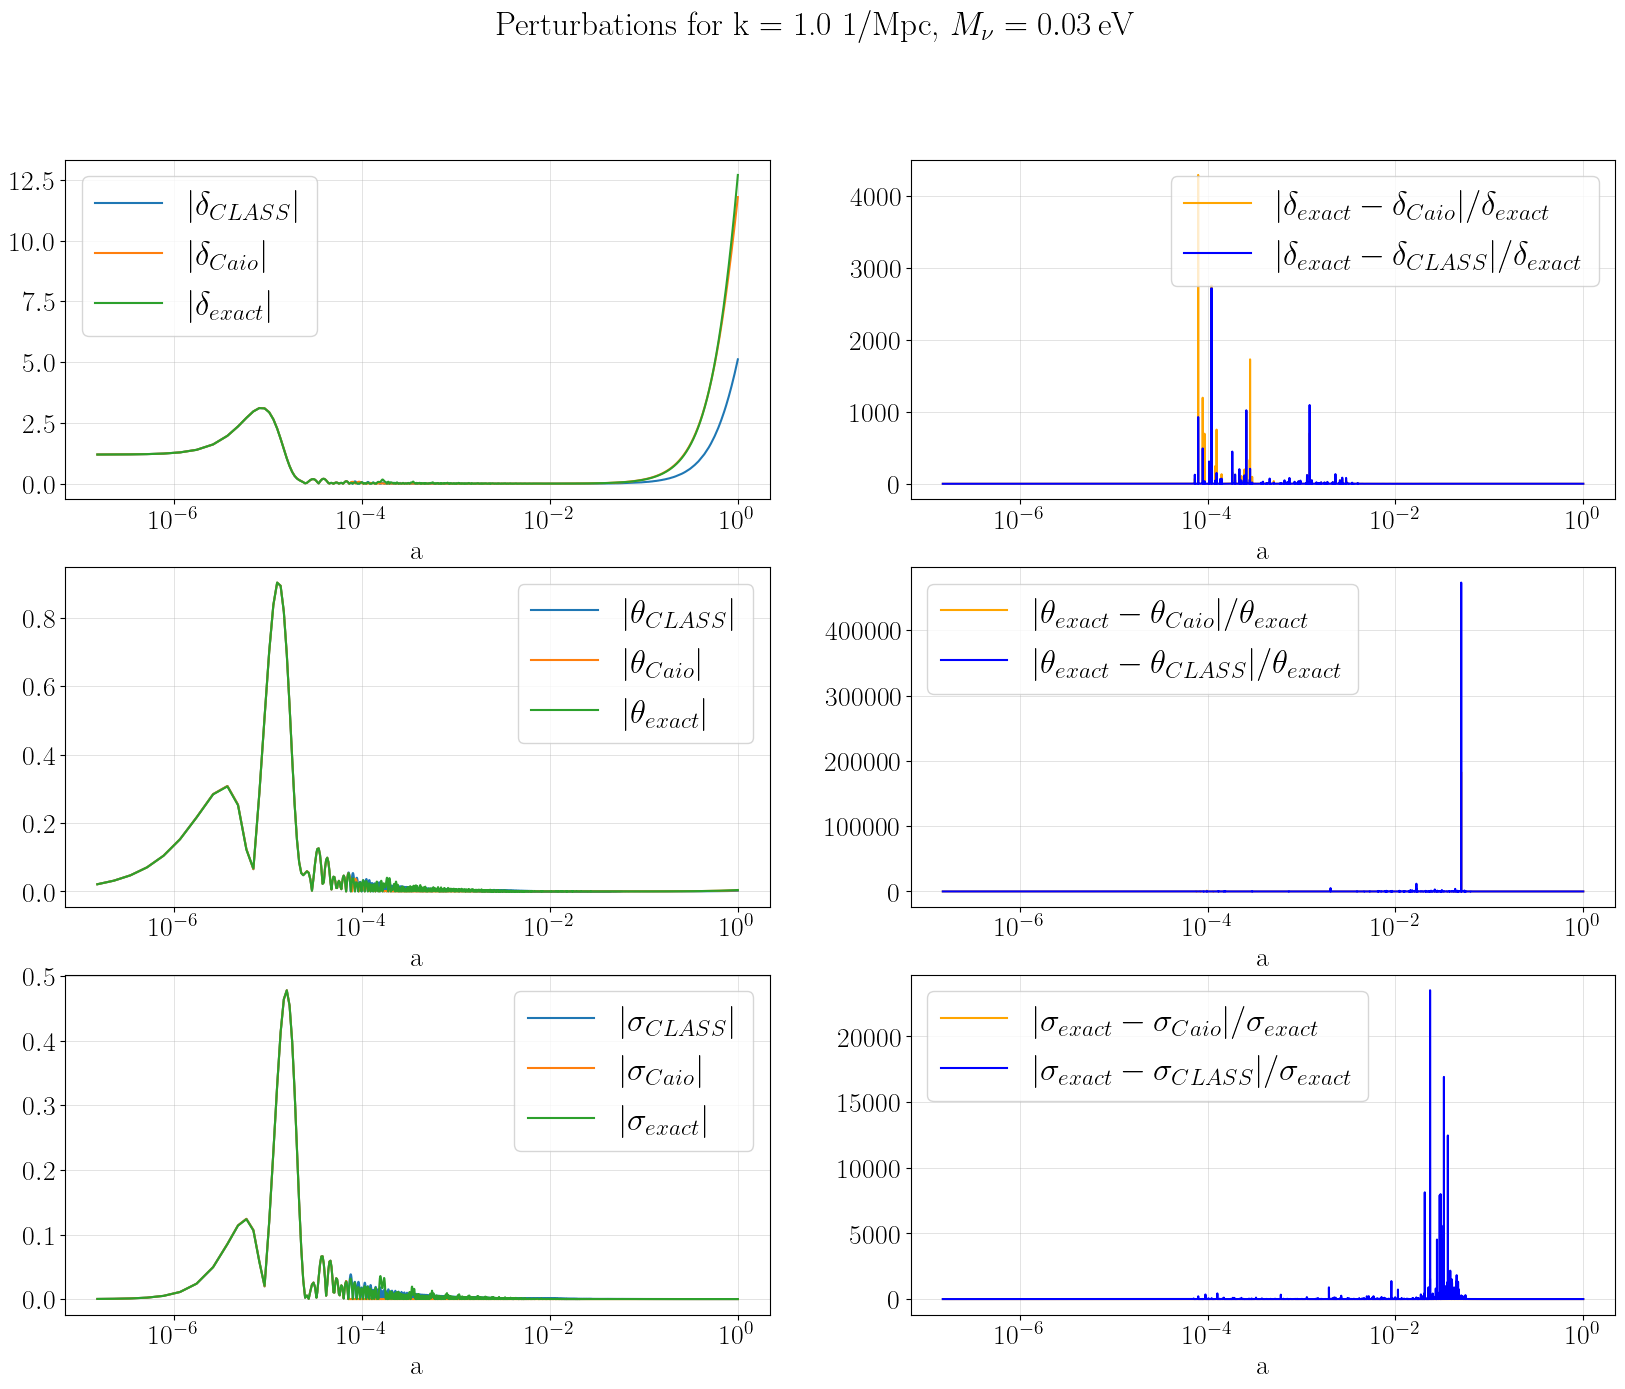

In [11]:
ncdm_pert_class = ncdmFA_CLASS.get_perturbations()['scalar']
ncdm_pert_caio = ncdmFA_caio.get_perturbations()['scalar']
ncdm_pert_no_FA = ncdm_noFA.get_perturbations()['scalar']

plt.rcParams.update({'font.size': 20})


for k_val_ind, k_val in enumerate(['0.008', '0.004', '0.001', '0.01', '0.1', '1.0']):
    ncdm_perturb_class = ncdm_pert_class[k_val_ind]
    ncdm_perturb_caio = ncdm_pert_caio[k_val_ind]
    ncdm_perturb_noFA = ncdm_pert_no_FA[k_val_ind]
    a = ncdm_perturb_class['a']

    # once again interpolating for robustness
    d_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['delta_ncdm[0]'])(a))
    theta_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['theta_ncdm[0]'])(a))
    sigma_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['shear_ncdm[0]'])(a))

    d_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['delta_ncdm[0]'])(a))
    theta_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['theta_ncdm[0]'])(a))
    sigma_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['shear_ncdm[0]'])(a))

    d_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['delta_ncdm[0]'])(a))
    theta_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['theta_ncdm[0]'])(a))
    sigma_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['shear_ncdm[0]'])(a))
                        
    
    
    fig, axes = plt.subplots(3,2, figsize = (20,15))

    for i, x_1, x_2, x_3, name in zip(range(3), [d_ncdm_class, theta_ncdm_class, sigma_ncdm_class], [d_ncdm_caio, theta_ncdm_caio, sigma_ncdm_caio], [d_ncdm_noFA, theta_ncdm_noFA, sigma_ncdm_noFA], [rf'\delta', rf'\theta', rf'\sigma']):
        axes[i,0].plot(a, x_1, label = rf'$|{name}_{{CLASS}}|$')
        axes[i,0].plot(a, x_2,label = rf'$|{name}_{{Caio}}|$')
        axes[i,0].plot(a, x_3,label = rf'$|{name}_{{exact}}|$')
        axes[i, 1].plot(a, np.abs(x_2-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{Caio}}| / {name}_{{exact}}$', color='orange')
        axes[i, 1].plot(a, np.abs(x_1-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{CLASS}}| / {name}_{{exact}}$', color='blue')
    for ax in axes.flat:
        ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.set_xlabel('a')
        
        ax.legend(fontsize='large')
        ax.grid(which="both",alpha = 0.5, linewidth=0.5)
    fig.suptitle(rf'Perturbations for k = {k_val} 1/Mpc, $M_\nu = {M_nu} \, \mathrm{{eV}}$')

/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.


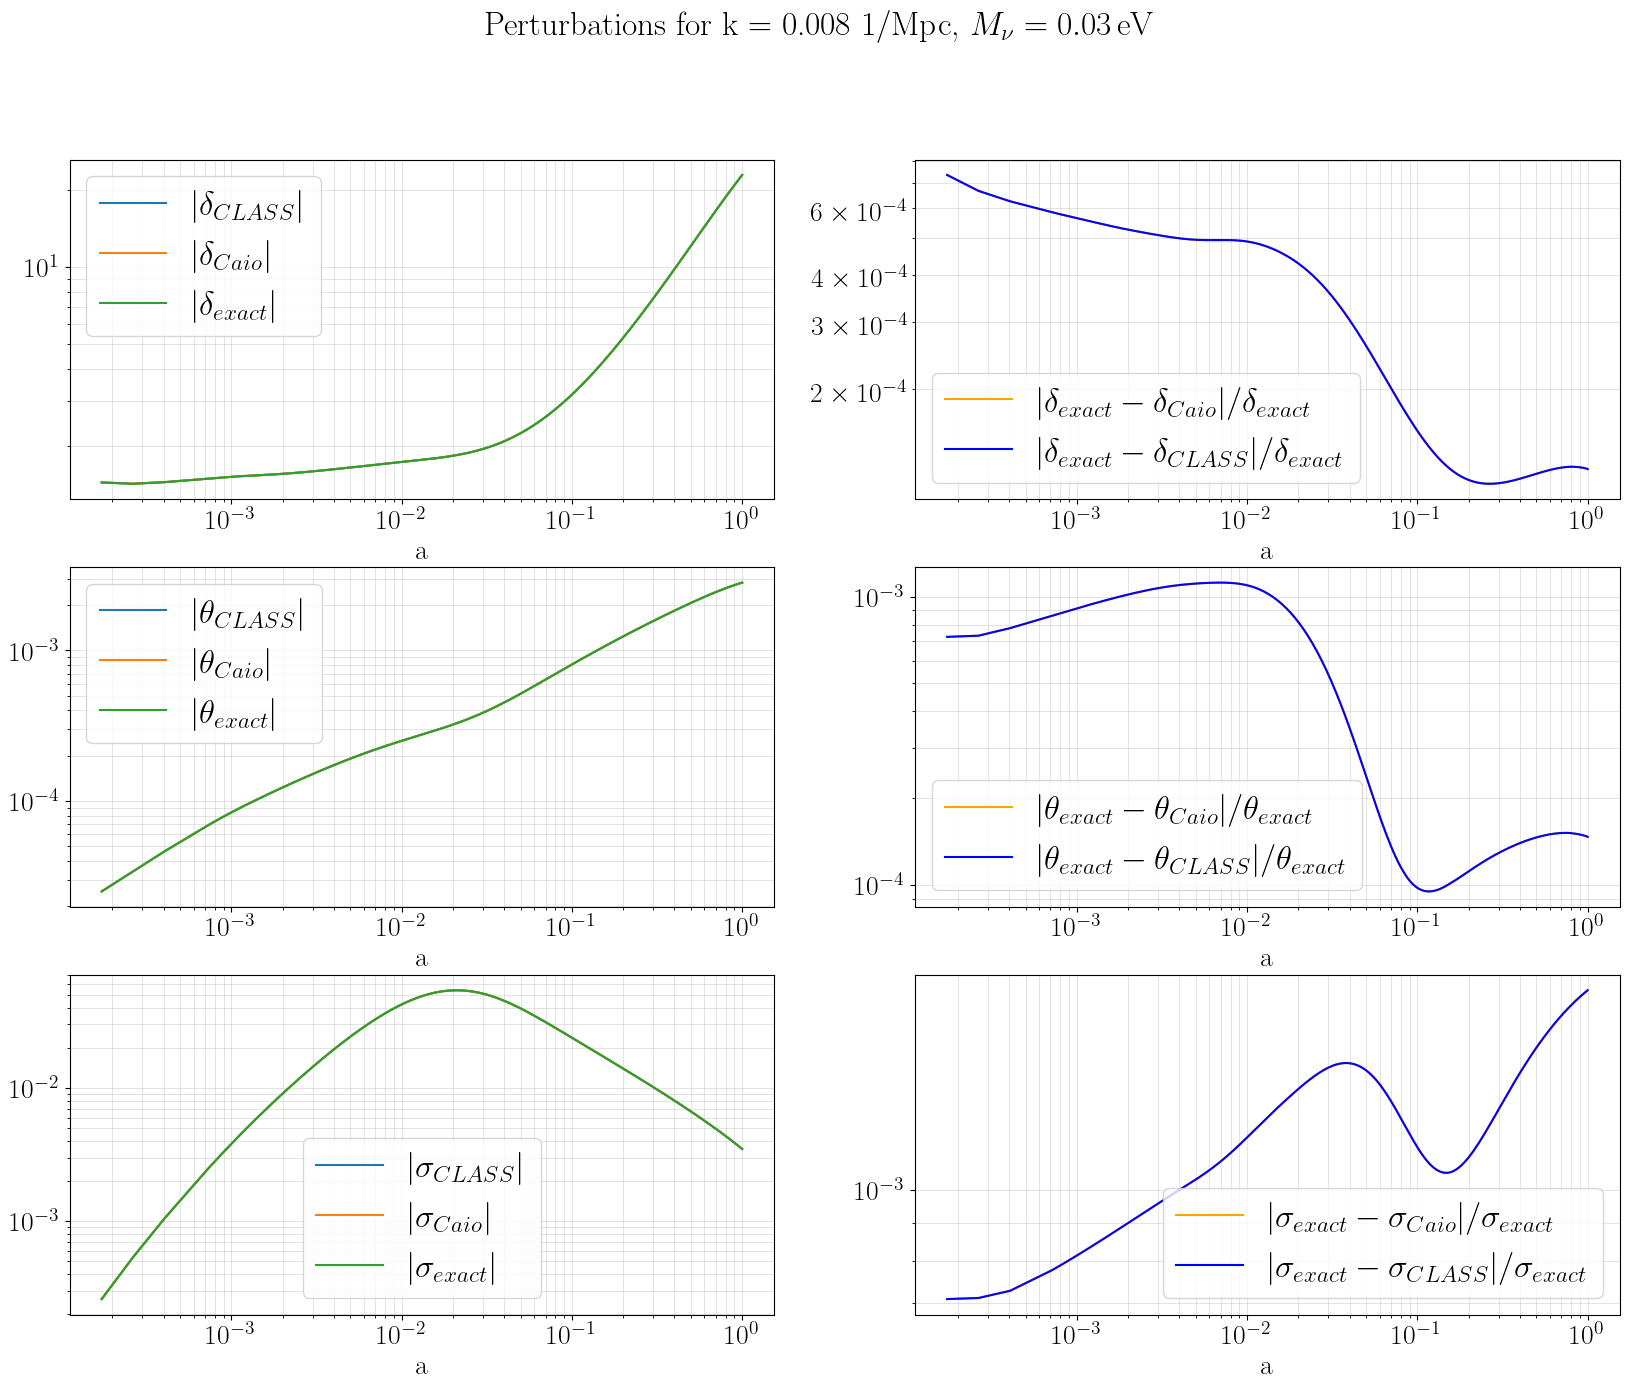

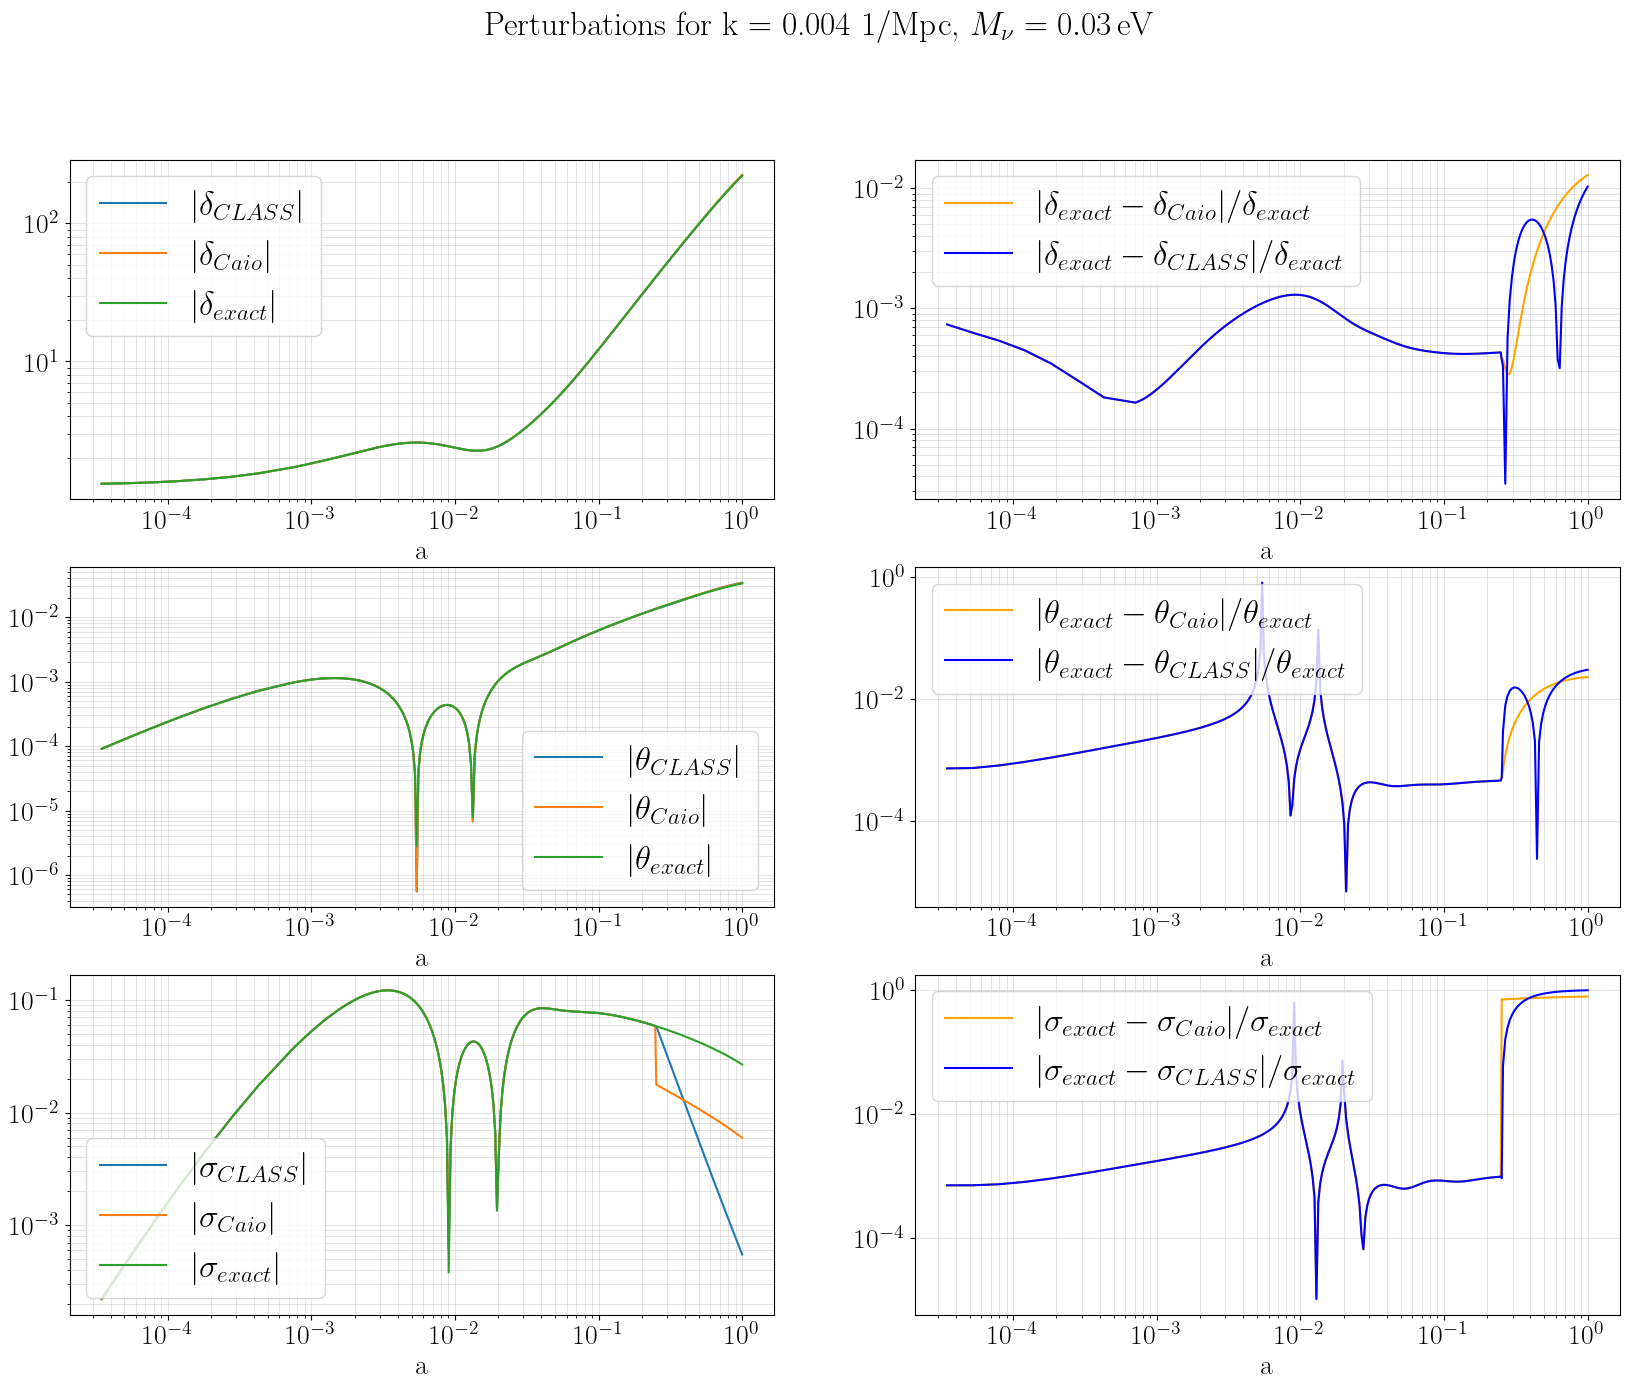

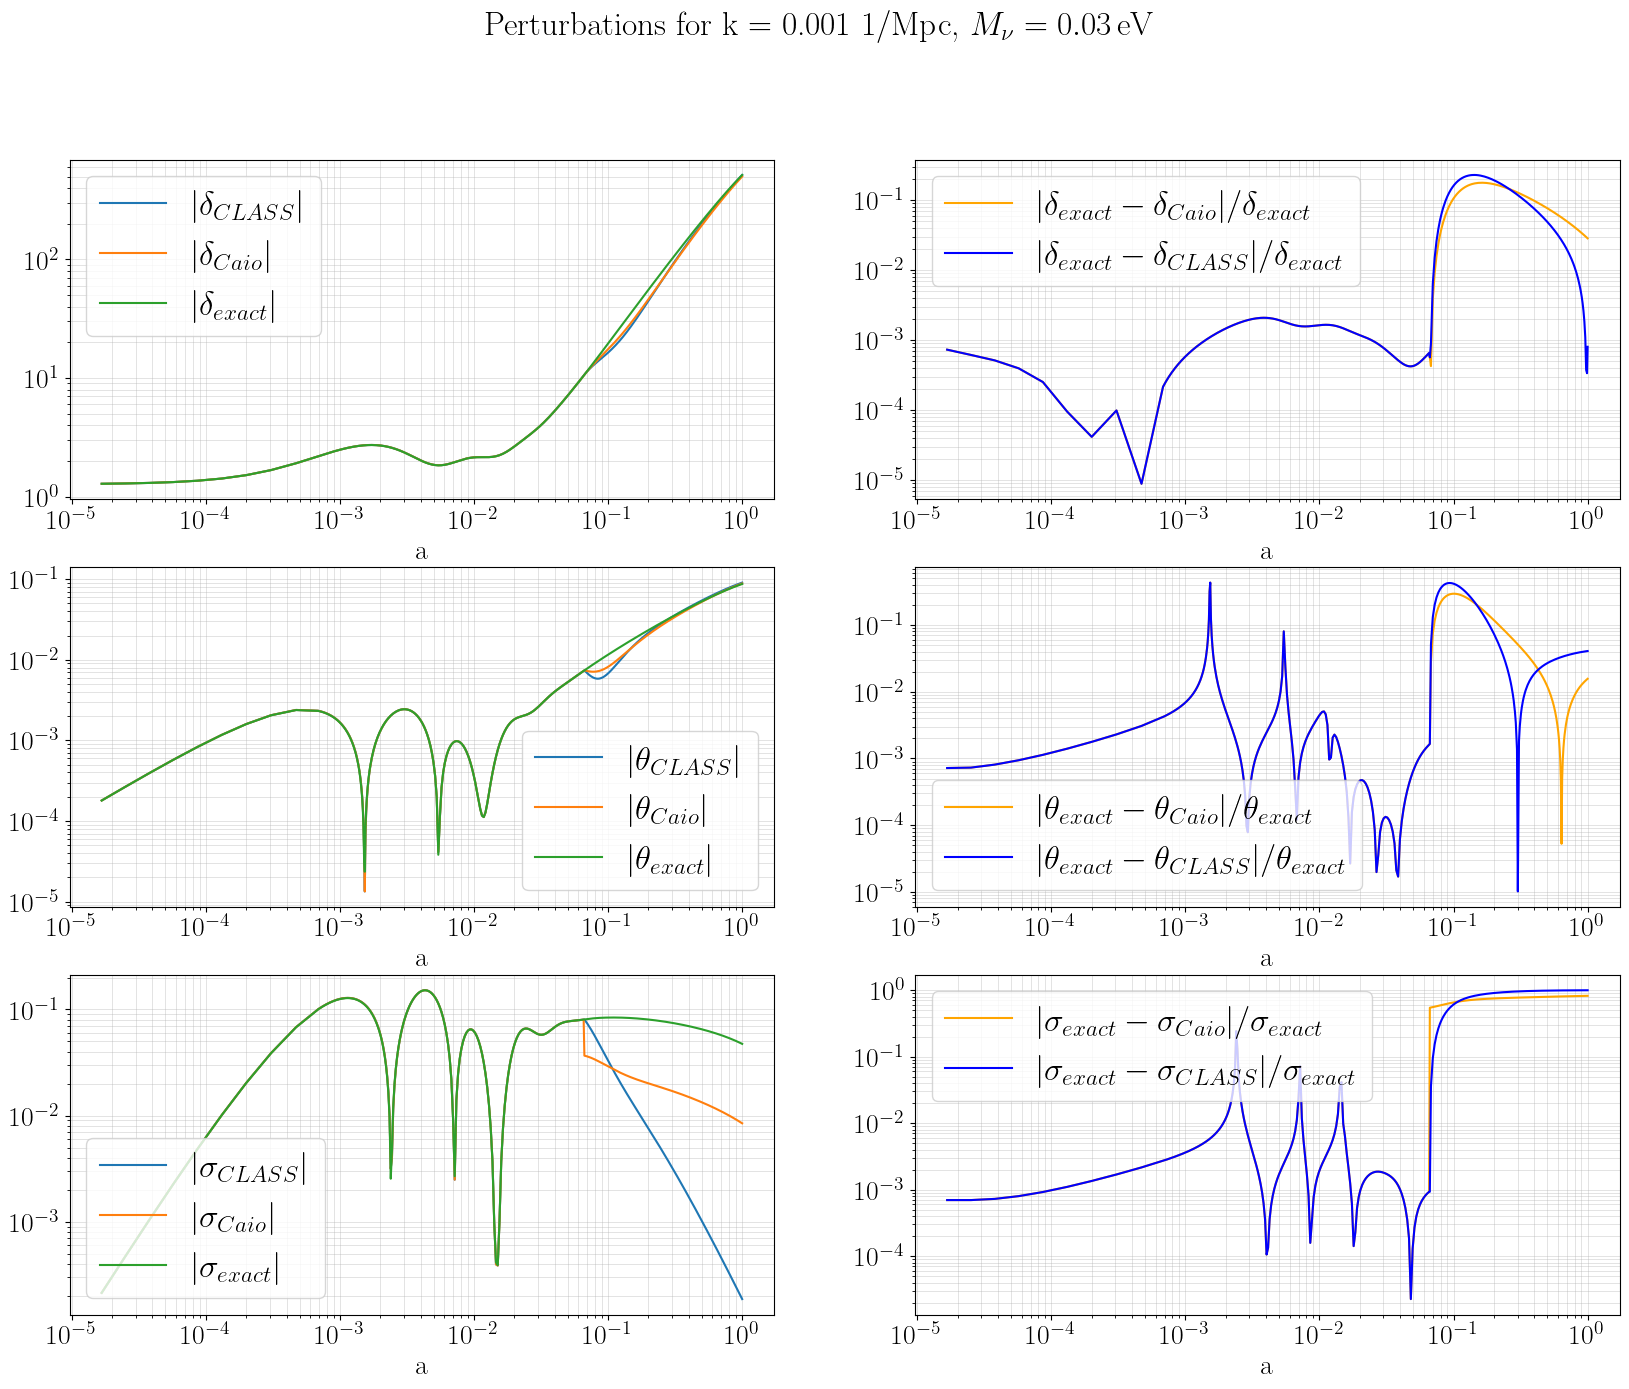

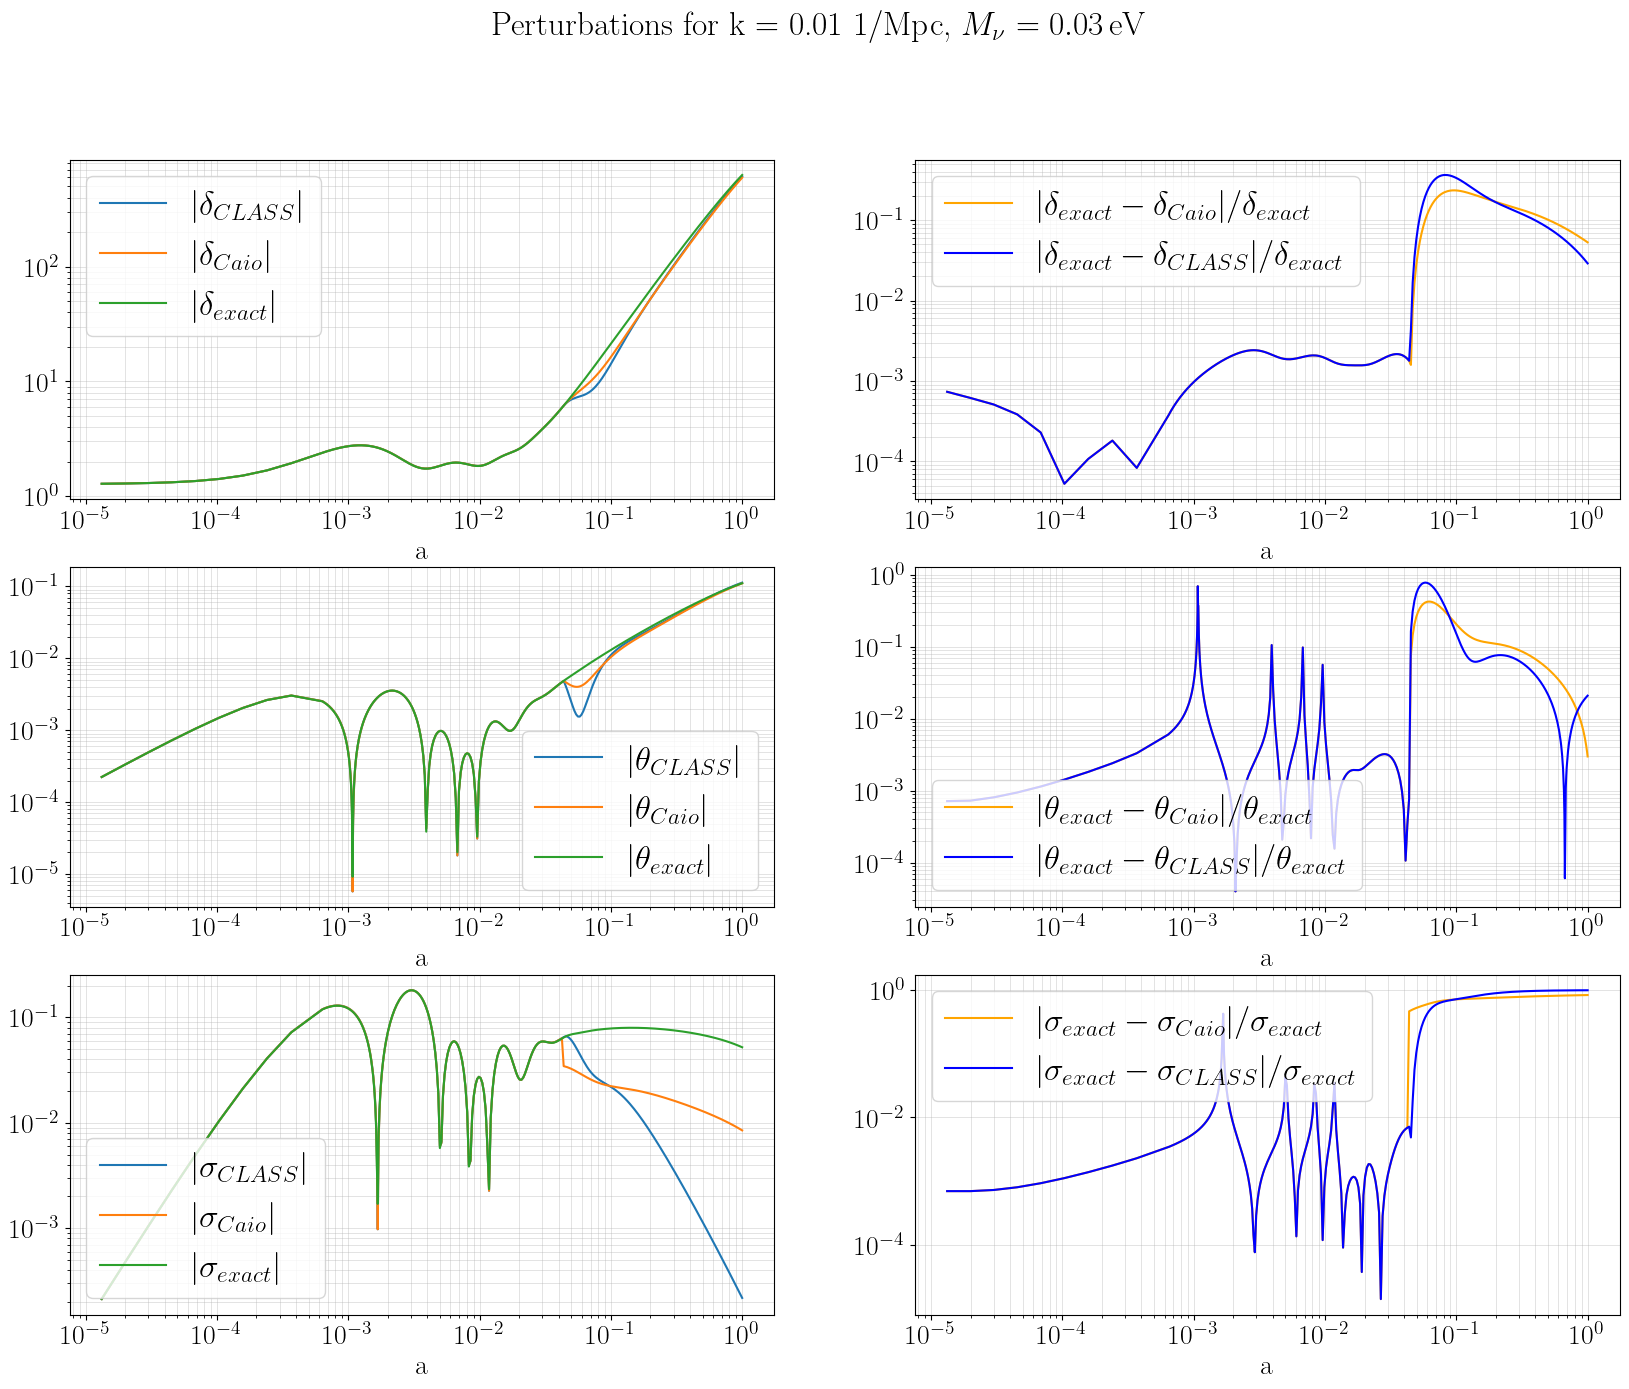

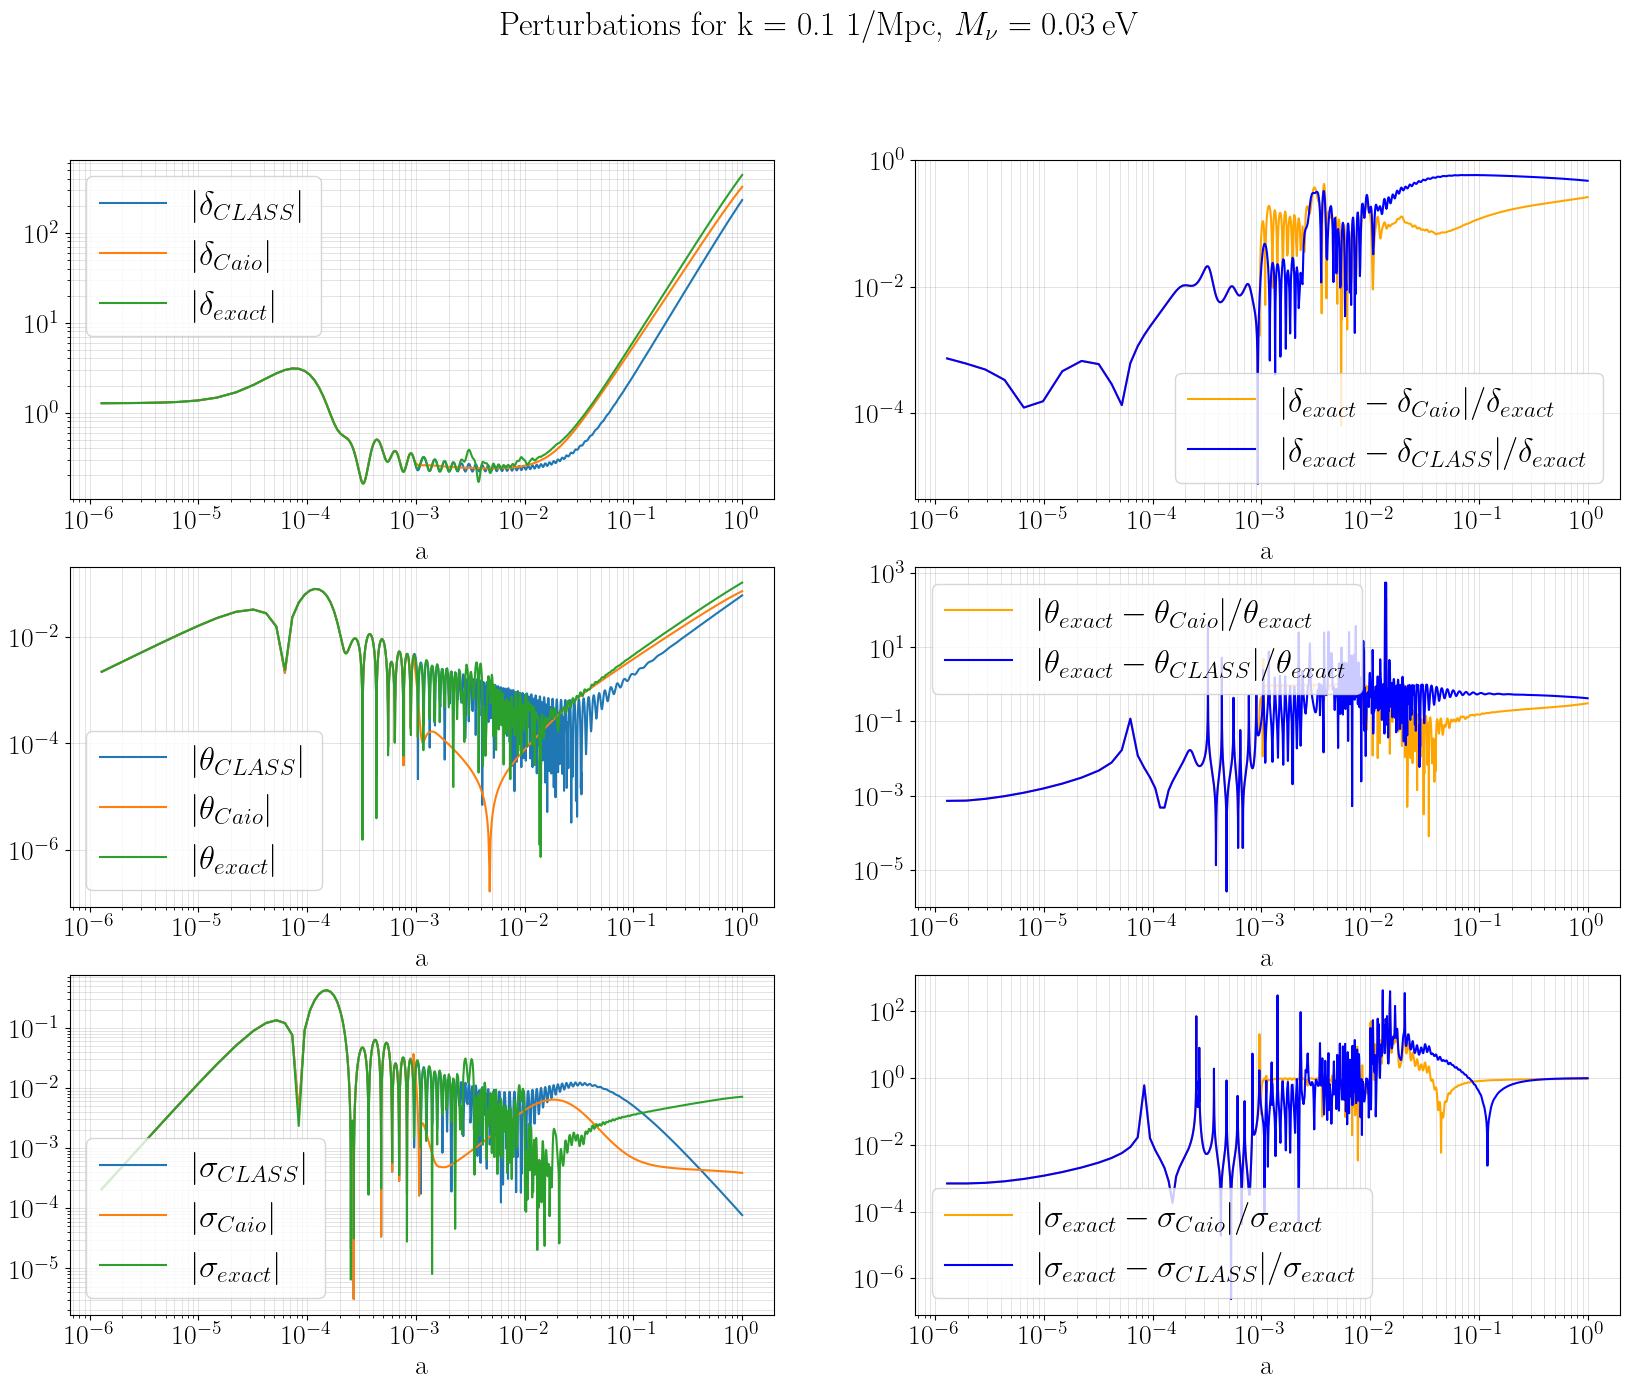

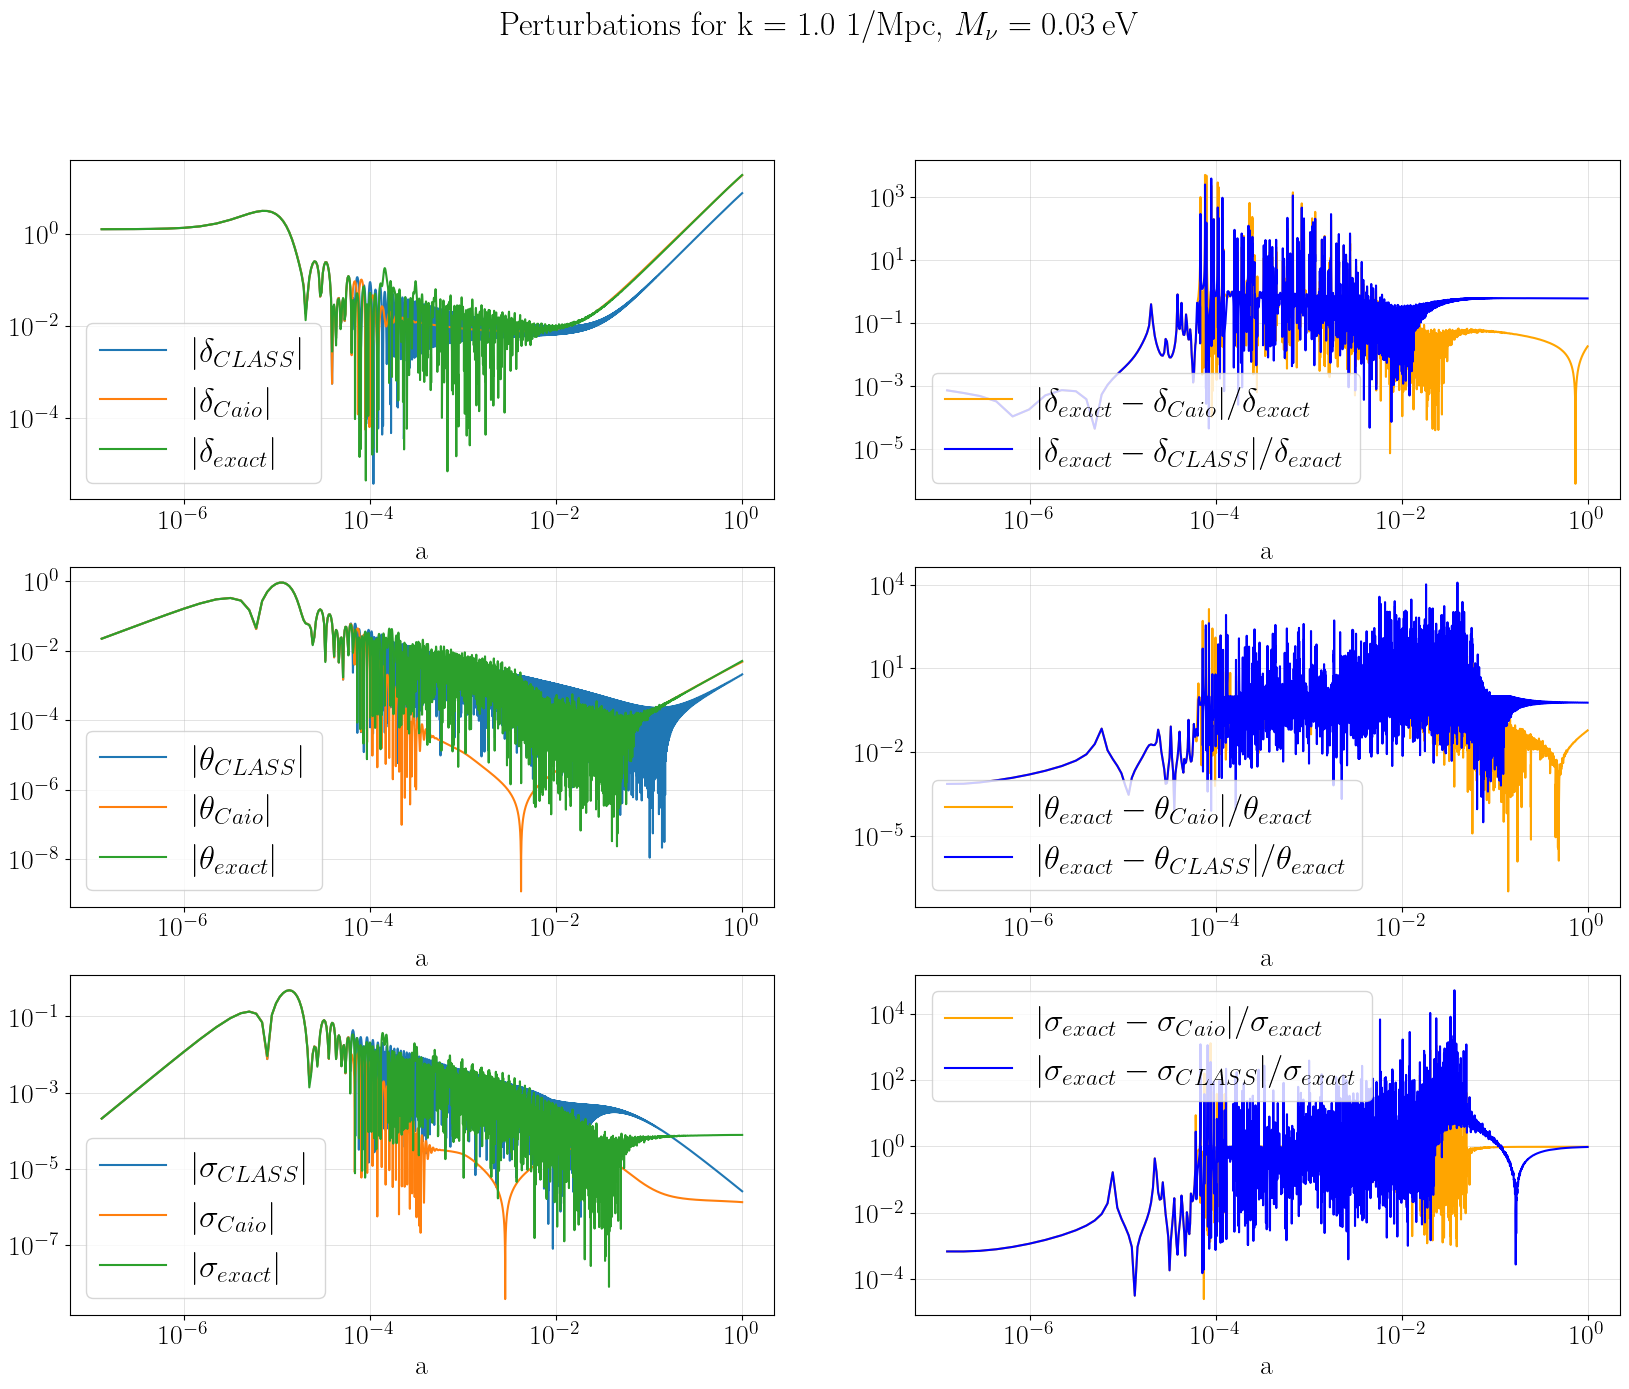

In [12]:
ncdm_pert_class = ncdmFA_CLASS.get_perturbations()['scalar']
ncdm_pert_caio = ncdmFA_caio.get_perturbations()['scalar']
ncdm_pert_no_FA = ncdm_noFA.get_perturbations()['scalar']

plt.rcParams.update({'font.size': 20})


for k_val_ind, k_val in enumerate(['0.008', '0.004', '0.001', '0.01', '0.1', '1.0']):
    ncdm_perturb_class = ncdm_pert_class[k_val_ind]
    ncdm_perturb_caio = ncdm_pert_caio[k_val_ind]
    ncdm_perturb_noFA = ncdm_pert_no_FA[k_val_ind]
    a = ncdm_perturb_class['a']

    # once again interpolating for robustness
    d_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['delta_ncdm[0]'])(a))
    theta_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['theta_ncdm[0]'])(a))
    sigma_ncdm_class = np.abs(sp.interpolate.interp1d(ncdm_perturb_class['a'], ncdm_perturb_class['shear_ncdm[0]'])(a))

    d_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['delta_ncdm[0]'])(a))
    theta_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['theta_ncdm[0]'])(a))
    sigma_ncdm_caio = np.abs(sp.interpolate.interp1d(ncdm_perturb_caio['a'], ncdm_perturb_caio['shear_ncdm[0]'])(a))

    d_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['delta_ncdm[0]'])(a))
    theta_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['theta_ncdm[0]'])(a))
    sigma_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['shear_ncdm[0]'])(a))
                        
    
    
    fig, axes = plt.subplots(3,2, figsize = (20,15))

    for i, x_1, x_2, x_3, name in zip(range(3), [d_ncdm_class, theta_ncdm_class, sigma_ncdm_class], [d_ncdm_caio, theta_ncdm_caio, sigma_ncdm_caio], [d_ncdm_noFA, theta_ncdm_noFA, sigma_ncdm_noFA], [rf'\delta', rf'\theta', rf'\sigma']):
        axes[i,0].plot(a, x_1, label = rf'$|{name}_{{CLASS}}|$')
        axes[i,0].plot(a, x_2,label = rf'$|{name}_{{Caio}}|$')
        axes[i,0].plot(a, x_3,label = rf'$|{name}_{{exact}}|$')
        axes[i, 1].plot(a, np.abs(x_2-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{Caio}}| / {name}_{{exact}}$', color='orange')
        axes[i, 1].plot(a, np.abs(x_1-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{CLASS}}| / {name}_{{exact}}$', color='blue')
    for ax in axes.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('a')
        
        ax.legend(fontsize='large')
        ax.grid(which="both",alpha = 0.5, linewidth=0.5)
    fig.suptitle(rf'Perturbations for k = {k_val} 1/Mpc, $M_\nu = {M_nu} \, \mathrm{{eV}}$')

In [ ]:
gbh_pert_class = gbh_FA_CLASS.get_perturbations()['scalar']
gbh_pert_caio = gbh_FA_caio.get_perturbations()['scalar']
ncdm_pert_no_FA = ncdm_noFA.get_perturbations()['scalar']

plt.rcParams.update({'font.size': 20})


for k_val_ind, k_val in enumerate(['0.008', '0.004', '0.001', '0.01', '0.1', '1.0']):
    gbh_perturb_class = gbh_pert_class[k_val_ind]
    gbh_perturb_caio = gbh_pert_caio[k_val_ind]
    ncdm_perturb_noFA = ncdm_pert_no_FA[k_val_ind]
    a = gbh_perturb_class['a']

    # once again interpolating for robustness
    d_ncdm_class = np.abs(sp.interpolate.interp1d(gbh_perturb_class['a'], gbh_perturb_class['delta_gbh'])(a))
    theta_ncdm_class = np.abs(sp.interpolate.interp1d(gbh_perturb_class['a'], gbh_perturb_class['theta_gbh'])(a))
    sigma_ncdm_class = np.abs(sp.interpolate.interp1d(gbh_perturb_class['a'], gbh_perturb_class['sigma_gbh'])(a))

    d_ncdm_caio = np.abs(sp.interpolate.interp1d(gbh_perturb_caio['a'], gbh_perturb_caio['delta_gbh'])(a))
    theta_ncdm_caio = np.abs(sp.interpolate.interp1d(gbh_perturb_caio['a'], gbh_perturb_caio['theta_gbh'])(a))
    sigma_ncdm_caio = np.abs(sp.interpolate.interp1d(gbh_perturb_caio['a'], gbh_perturb_caio['sigma_gbh'])(a))

    d_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['delta_ncdm[0]'])(a))
    theta_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['theta_ncdm[0]'])(a))
    sigma_ncdm_noFA = np.abs(sp.interpolate.interp1d(ncdm_perturb_noFA['a'], ncdm_perturb_noFA['shear_ncdm[0]'])(a))
                        
    
    
    fig, axes = plt.subplots(3,2, figsize = (20,15))

    for i, x_1, x_2, x_3, name in zip(range(3), [d_ncdm_class, theta_ncdm_class, sigma_ncdm_class], [d_ncdm_caio, theta_ncdm_caio, sigma_ncdm_caio], [d_ncdm_noFA, theta_ncdm_noFA, sigma_ncdm_noFA], [rf'\delta', rf'\theta', rf'\sigma']):
        axes[i,0].plot(a, x_1, label = rf'$|{name}_{{GBH/CLASS}}|$')
        axes[i,0].plot(a, x_2,label = rf'$|{name}_{{GBH/Caio}}|$')
        axes[i,0].plot(a, x_3,label = rf'$|{name}_{{exact}}|$')
        axes[i, 1].plot(a, np.abs(x_2-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{GBH/Caio}}| / {name}_{{exact}}$', color='orange')
        axes[i, 1].plot(a, np.abs(x_1-x_3)/x_3, 'r', label = rf'$| {name}_{{exact}}- {name}_{{GBH/CLASS}}| / {name}_{{exact}}$', color='blue')
    for ax in axes.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('a')
        
        ax.legend(fontsize='large')
        ax.grid(which="both",alpha = 0.5, linewidth=0.5)
    fig.suptitle(rf'Perturbations for k = {k_val} 1/Mpc, $M_\nu = {M_nu} \, \mathrm{{eV}}$')

/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
/rds/general/user/an421/home/anaconda3/envs/myenv/lib/python3.7/site-packages/ipykernel_launcher.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.


In [ ]:
# ncdm_all_perturb = ncdm.get_perturbations()['scalar']
# gbh_all_perturb = gbh.get_perturbations()['scalar']

# for k_val_ind, k_val in enumerate(['0.008', '0.004', '0.001', '0.01', '0.1', '1.0']):
#     ncdm_perturb = ncdm_all_perturb[k_val_ind]
#     gbh_perturb = gbh_all_perturb[k_val_ind]
#     a = gbh_perturb['a']

#     # once again interpolating for robustness
#     d_ncdm = np.abs(sp.interpolate.interp1d(ncdm_perturb['a'], ncdm_perturb['delta_ncdm[0]'])(a))
#     theta_ncdm = np.abs(sp.interpolate.interp1d(ncdm_perturb['a'], ncdm_perturb['theta_ncdm[0]'])(a))
#     sigma_ncdm = np.abs(sp.interpolate.interp1d(ncdm_perturb['a'], ncdm_perturb['shear_ncdm[0]'])(a))
                        
#     d_gbh = np.abs(sp.interpolate.interp1d(gbh_perturb['a'], gbh_perturb['delta_gbh'])(a))
#     theta_gbh = np.abs(sp.interpolate.interp1d(gbh_perturb['a'], gbh_perturb['theta_gbh'])(a))
#     sigma_gbh = np.abs(sp.interpolate.interp1d(gbh_perturb['a'], gbh_perturb['sigma_gbh'])(a))
    
#     fig, axes = plt.subplots(3,2, figsize = (8,8))

#     for i, x_ncdm, x_gbh, name in zip(range(3), [d_ncdm, theta_ncdm, sigma_ncdm], [d_gbh, theta_gbh, sigma_gbh], [rf'\delta', rf'\theta', rf'\sigma']):
#         axes[i,0].plot(a, x_ncdm, label = rf'$|{name}_{{ncdm}}|$')
#         axes[i,0].plot(a, x_gbh,label = rf'$|{name}_{{gbh}}|$')
#         axes[i, 1].plot(a, np.abs(x_ncdm-x_gbh)/x_ncdm, 'r', label = rf'$| {name}_{{ncdm}}- {name}_{{gbh}}| / {name}_{{ncdm}}$')
#     for ax in axes.flat:
#         ax.set_xscale('log')
#         ax.set_yscale('log')
#         ax.set_xlabel('a')
        
#         ax.legend()
#         ax.grid(which="both",alpha = 0.5, linewidth=0.5)
#     fig.suptitle(rf'Perturbations for k = {k_val} 1/Mpc, $M_\nu = {M_nu} \, \text{{eV}}$')

# Transfer Functions
get_transfer() returns a list of k-values and transfer functions for various species for a given redshift. Note that the 'z_pk' must be higher than the redshift value that you ask for

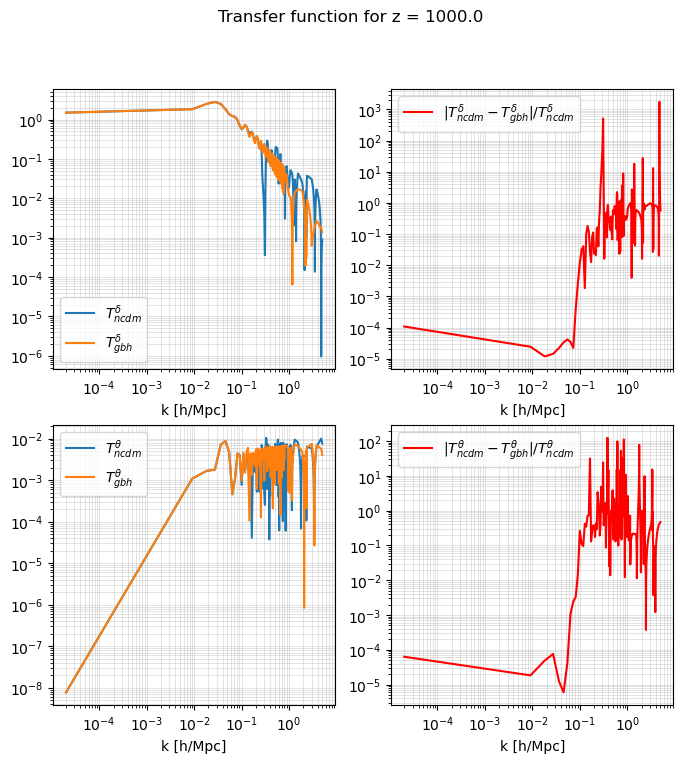

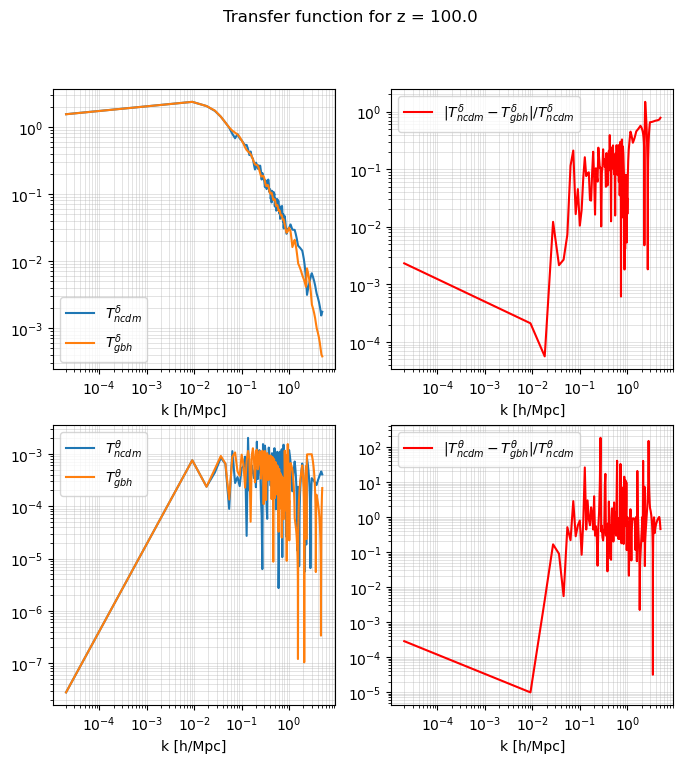

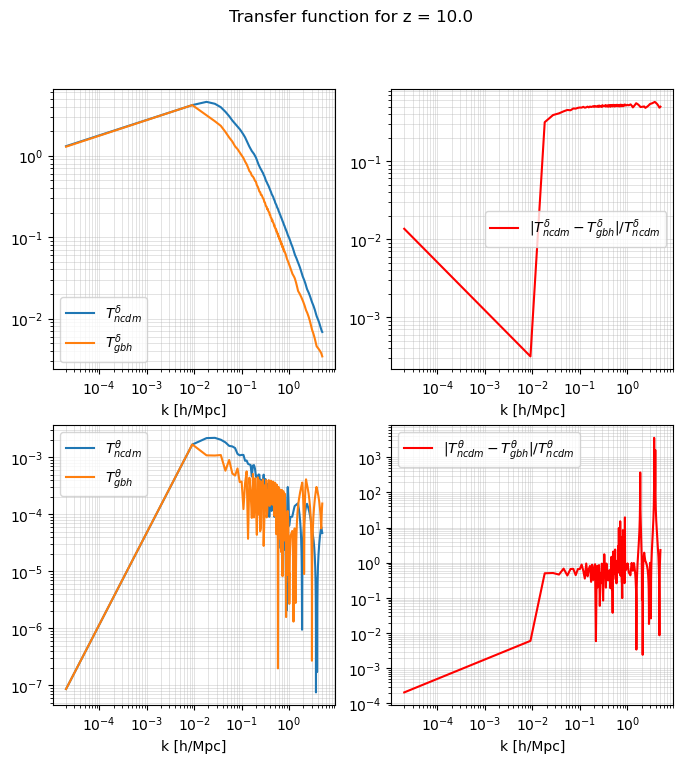

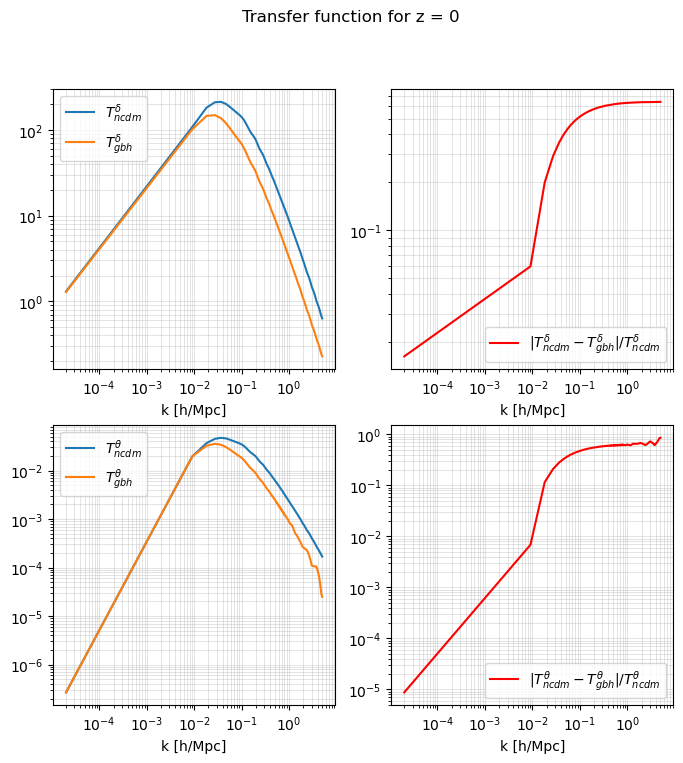

In [ ]:
for z_ind, z_val in enumerate([1e3, 1e2, 1e1, 0]):
    ncdm_transfer = ncdm.get_transfer(z_val)
    gbh_transfer = gbh.get_transfer(z_val)
    k = np.linspace(2e-5,5,550)

    # once again interpolating for robustness
    d_ncdm = np.abs(sp.interpolate.interp1d(ncdm_transfer['k (h/Mpc)'], ncdm_transfer['d_ncdm[0]'])(k))
    theta_ncdm = np.abs(sp.interpolate.interp1d(ncdm_transfer['k (h/Mpc)'], ncdm_transfer['t_ncdm[0]'])(k))
   
                        
    d_gbh = np.abs(sp.interpolate.interp1d(gbh_transfer['k (h/Mpc)'], gbh_transfer['d_gbh'])(k))
    theta_gbh = np.abs(sp.interpolate.interp1d(gbh_transfer['k (h/Mpc)'], gbh_transfer['t_gbh'])(k))

    
    fig, axes = plt.subplots(2,2, figsize = (8,8))

    for i, x_ncdm, x_gbh, name in zip(range(3), [d_ncdm, theta_ncdm], [d_gbh, theta_gbh], [rf'\delta', rf'\theta']):
        axes[i,0].plot(k, x_ncdm, label = rf'$T^{name}_{{ncdm}}$')
        axes[i,0].plot(k, x_gbh,label = rf'$T^{name}_{{gbh}}$')
        axes[i, 1].plot(k, np.abs(x_ncdm-x_gbh)/x_ncdm, 'r', label = rf'$| T^{name}_{{ncdm}}- T^{name}_{{gbh}}| / T^{name}_{{ncdm}}$')
    for ax in axes.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('k [h/Mpc]')
        
        ax.legend()
        ax.grid(which="both",alpha = 0.5, linewidth=0.5)
    fig.suptitle(f'Transfer function for z = {z_val} ')

# Observables

In [ ]:
#plt.rcParams['figure.dpi'] = 150

def plot_palette(palette):
    return mpl.rc_context({"axes.prop_cycle": cycler(color=palette)})




def plot_cl_and_fractional_residuals_no_norm_TTTEEE(models, ref_model, labels = [], Planck = True, 
                                                    xscale_plots = 'linear', yscale_plots = 'linear', 
                                                    xscale_residuals = 'linear', yscale_residuals = 'linear', lmax = 5000, fontsize = 10, 
                                                    legend_fontsize = 13, y_residual_max = 0.4):
    T_CMB=2.725

    if type(models) == dict:
        n = len(models.keys())
    else:
        n = len(models)
    
    with plot_palette(cmr.get_sub_cmap("cmr.rainforest", 0.15, 0.85, N=n).colors):
    
        fig, axs = plt.subplots(6, 1, gridspec_kw={'height_ratios': [1.5, 2, 1.5, 2, 1.5,2]}, figsize=(12,18), sharex = True)
    
    ##TT, TE, EE Data and Residuals
        for ind, corr in enumerate(['tt','te', 'ee']):
            cl_row_ind = 2*ind
            residual_row_ind = 2*ind+1
            axs[cl_row_ind].set_xscale(xscale_plots)
            axs[cl_row_ind].set_yscale(yscale_plots)
        #axs[cl_row_ind, column_ind].set_xlabel('$\\ell$', fontsize=20)
            axs[cl_row_ind].set_xlabel('$\\ell$', fontsize=fontsize)
            axs[cl_row_ind].set_ylabel('$\\ell (\\ell+1)/2\\pi * C_\\ell^\\mathrm{' +str(corr).upper() +'}  [ 10^2 mK^2] $',  fontsize = fontsize)
            axs[cl_row_ind].set_xlim(2,lmax)
            if type(models)==dict:
                for key in models.keys():
                    
                    ll = models[key].raw_cl()['ell']
                    plot_vals = models[key].raw_cl()[corr]
                    axs[cl_row_ind].plot(ll,plot_vals*(ll)*(ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100), label = key)
                if Planck:
                    if corr=='tt':
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_TT, Planck_TT, yerr=[Planck_TT_neg_err, Planck_TT_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )  
                    elif corr == 'ee':
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_EE, Planck_EE, yerr=[Planck_EE_neg_err, Planck_EE_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )
                    else:
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_TE, Planck_TE, yerr=[Planck_TE_neg_err, Planck_TE_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )
                    [bar.set_alpha(0.5) for bar in bars]
                    [cap.set_alpha(0.5) for cap in caps]
                
            elif type(models) == list:
                for label_ind, model in enumerate(models):
                    ll = model.raw_cl()['ell']
                    plot_vals = model.raw_cl()[corr]
                    axs[cl_row_ind].plot(ll,plot_vals*(ll)*(ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100), label = labels[label_ind])
                if Planck:
                    if corr=='tt':
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_TT, Planck_TT, yerr=[Planck_TT_neg_err, Planck_TT_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )
                    elif corr == 'ee':
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_EE, Planck_EE, yerr=[Planck_EE_neg_err, Planck_EE_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )
                    else:
                        markers, caps, bars = axs[cl_row_ind].errorbar(Planck_ll_TE, Planck_TE, yerr=[Planck_TE_neg_err, Planck_TE_pos_err], 
                                                                       fmt='.', color='black', capsize=4, markersize = 2, zorder =1 )
                    [bar.set_alpha(0.5) for bar in bars]
                    [cap.set_alpha(0.5) for cap in caps]    
            
            axs[0].legend(loc=1, prop={'size': legend_fontsize})
    
            
            #axs[cl_row_ind, column_ind].set_xticklabels([])
            # Plot Residuals
            #axs[residual_row_ind, column_ind].sharex(axs[cl_row_ind, column_ind])
            axs[residual_row_ind].set_xscale(xscale_residuals)
            axs[residual_row_ind].set_yscale(yscale_residuals)
            axs[residual_row_ind].set_xlabel('$\\ell$',  fontsize = fontsize)
            axs[residual_row_ind].set_ylabel('$(C_\\ell^\\mathrm{' +str(corr).upper()+'} - C_{\\ell, ref}^\\mathrm{' +str(corr).upper() +'}) /  C_{\\ell, ref}^\\mathrm{' +str(corr).upper() +'}$',  fontsize = fontsize)
            axs[residual_row_ind].set_xlim(2,lmax)
            axs[residual_row_ind].set_ylim(-y_residual_max, y_residual_max)
            
            
            if type(models)==dict:
                if corr in ['tt','ee']:
                    for key in models.keys():
                        ll = models[key].raw_cl()['ell'][2:]
                        plot_vals = models[key].raw_cl()[corr][2:]
                        ref_vals = ref_model.raw_cl()[corr][2:]
                        axs[residual_row_ind].plot(ll,((plot_vals-ref_vals)/ref_vals), label = key)
                    if Planck:
                        if corr=='tt':
                            ref_vals_planck_ll_indices = [np.where(ll == round(Planck_ll_val))[0][0] for Planck_ll_val in Planck_ll_TT]
                            ref_planck_vals = np.asarray([ref_vals[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_ll = np.asarray([ll[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_vals = ref_planck_vals*(ref_planck_ll)*(ref_planck_ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100)
                            markers, caps, bars =axs[residual_row_ind].errorbar(Planck_ll_TT, (Planck_TT-ref_planck_vals)/ref_planck_vals, 
                                                                                                      yerr=[Planck_TT_neg_err/ref_planck_vals, 
                                                                                                            Planck_TT_pos_err/ref_planck_vals], 
                                                                                                      fmt='.', color='black', capsize=4, markersize = 2, zorder =100 )
                        else:
                            ref_vals_planck_ll_indices = [np.where(ll == round(Planck_ll_val))[0][0] for Planck_ll_val in Planck_ll_EE]
                            ref_planck_vals = np.asarray([ref_vals[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_ll = np.asarray([ll[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_vals = ref_planck_vals*(ref_planck_ll)*(ref_planck_ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100)
                            markers, caps, bars = axs[residual_row_ind].errorbar(Planck_ll_EE, (Planck_EE-ref_planck_vals)/ref_planck_vals, 
                                                                                                      yerr=[Planck_EE_neg_err/ref_planck_vals, 
                                                                                                            Planck_EE_pos_err/ref_planck_vals], 
                                                                                                      fmt='.', color='black', capsize=4, markersize = 2, zorder =100 )
                        [bar.set_alpha(0.5) for bar in bars]
                        [cap.set_alpha(0.5) for cap in caps]
                if corr == 'te':
                    for key in models.keys():
                        ll = models[key].raw_cl()['ell'][2:]
                        plot_vals = models[key].raw_cl()[corr][2:]
                        ref_vals_tt = ref_model.raw_cl()['tt'][2:]
                        ref_vals_ee = ref_model.raw_cl()['ee'][2:]
                        ref_vals_te = ref_model.raw_cl()['te'][2:]
                        axs[residual_row_ind].plot(ll,((plot_vals-ref_vals_te)/np.sqrt(ref_vals_tt*ref_vals_ee)), label = key)
                    axs[residual_row_ind].set_ylabel('$(C_\\ell^\\mathrm{' +str(corr).upper() 
                                                     +'} - C_{\\ell, ref}^\\mathrm{' +str(corr).upper() 
                                                     +'})/ \\sqrt{C_{\\ell, ref}^\\mathrm{TT} *C_{\\ell, ref}^\\mathrm{EE}}$',  fontsize = fontsize)
                    if Planck:
                        print("YO U GOTTA FIX THIS, NO TE RESIDUALS")
                        pass
                        #axs[1, column_ind].errorbar(Planck_ll_TE, (Planck_TE-Planck_TE_fit)/Planck_TE_fit, yerr=[Planck_TE_neg_err/Planck_TE_fit, Planck_TE_pos_err/Planck_TE_fit], fmt='.', color='black', capsize=4, markersize = 2)
                        
            elif type(models) == list:
                if corr in ['tt','ee']:
                    for label_ind, model in enumerate(models):
                        ll = model.raw_cl()['ell'][2:]
                        plot_vals = model.raw_cl()[corr][2:]
                        ref_vals = ref_model.raw_cl()[corr][2:]
                        axs[residual_row_ind].plot(ll,((plot_vals-ref_vals)/ref_vals), label = labels[label_ind])
                    if Planck:
                        if corr=='tt':
                            ref_vals_planck_ll_indices = [np.where(ll == round(Planck_ll_val))[0][0] for Planck_ll_val in Planck_ll_TT]
                            ref_planck_vals = np.asarray([ref_vals[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_ll = np.asarray([ll[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_vals = ref_planck_vals*(ref_planck_ll)*(ref_planck_ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100)
                            markers, caps, bars = axs[residual_row_ind].errorbar(Planck_ll_TT, (Planck_TT-ref_planck_vals)/ref_planck_vals, 
                                                                                                      yerr=[Planck_TT_neg_err/ref_planck_vals, 
                                                                                                            Planck_TT_pos_err/ref_planck_vals], 
                                                                                                      fmt='.', color='black', capsize=4, markersize = 2, zorder =100 )
                        else:
                            ref_vals_planck_ll_indices = [np.where(ll == round(Planck_ll_val))[0][0] for Planck_ll_val in Planck_ll_EE]
                            ref_planck_vals = np.asarray([ref_vals[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_ll = np.asarray([ll[ref_vals_planck_ll_index] for ref_vals_planck_ll_index in ref_vals_planck_ll_indices])
                            ref_planck_vals = ref_planck_vals*(ref_planck_ll)*(ref_planck_ll+1)*T_CMB**2*(10**6)/(2.*math.pi*100)
                            markers, caps, bars = axs[residual_row_ind].errorbar(Planck_ll_EE, (Planck_EE-ref_planck_vals)/ref_planck_vals, 
                                                                                                      yerr=[Planck_EE_neg_err/ref_planck_vals, 
                                                                                                            Planck_EE_pos_err/ref_planck_vals], 
                                                                                                      fmt='.', color='black', capsize=4, markersize = 2, zorder =100 )
                        [bar.set_alpha(0.5) for bar in bars]
                        [cap.set_alpha(0.5) for cap in caps]
                if corr == 'te':
                    for label_ind, model in enumerate(models):
                        ll = model.raw_cl()['ell'][2:]
                        plot_vals = model.raw_cl()[corr][2:]
                        ref_vals_tt = ref_model.raw_cl()['tt'][2:]
                        ref_vals_ee = ref_model.raw_cl()['ee'][2:]
                        ref_vals_te = ref_model.raw_cl()['te'][2:]
                        axs[residual_row_ind].plot(ll,((plot_vals-ref_vals_te)/np.sqrt(0.5*(ref_vals_tt*ref_vals_ee+(ref_vals_te)**2))), label = labels[label_ind])
                    axs[residual_row_ind].set_ylabel('$(C_\\ell^\\mathrm{' +str(corr).upper() 
                                                     +'} - C_{\\ell, ref}^\\mathrm{' +str(corr).upper() 
                                                     +'})/ \\sqrt{ 0.5* (C_{\\ell, ref}^\\mathrm{TT} *C_{\\ell, ref}^\\mathrm{EE} + (C_{\\ell, ref}^\\mathrm{' 
                                                     +str(corr).upper() +'})^2 )}$',  fontsize = 5)
    
                    if Planck:
                        print("YO U GOTTA FIX THIS, NO TE RESIDUALS")
                        pass
                        #axs[1, column_ind].errorbar(Planck_ll_TE, (Planck_TE-Planck_TE_fit)/Planck_TE_fit, yerr=[Planck_TE_neg_err/Planck_TE_fit, Planck_TE_pos_err/Planck_TE_fit], fmt='.', color='black', capsize=4, markersize = 2)
            #fig.tight_layout()
            fig.subplots_adjust(hspace=0)


In [ ]:
def plot_pk_and_fractional_residuals_no_norm(models, ref_model, labels = [], 
                                                xscale_plots = 'log', yscale_plots = 'log', xscale_residuals = 'log', 
                                                  yscale_residuals = 'linear', fontsize = 10, 
                                                  legend_fontsize = 13, filename = '', colorbar_lims = [], 
                                                  colorbar_label = '', legend = True, z = 0, h_factor = True):

    if type(models) == dict:
        n = len(models.keys())
    else:
        n = len(models)
    cmap = cmr.get_sub_cmap("cmr.rainforest", 0.15, 0.85, N=n)
    with plot_palette(cmap.colors):
    
        fig, axs = plt.subplots(1, 2, figsize=(8,4))
        kk = np.logspace(-4,np.log10(3),1000)
        axs[0].set_xscale(xscale_plots)
        axs[0].set_yscale(yscale_plots)
        
        if h_factor:
            h = ref_model.h()
            axs[0].set_xlim(h*kk[0],h*kk[-1])
            axs[0].set_xlabel(r'$k \,\,\,\, [h/ \mathrm{Mpc}]$',  fontsize = fontsize)
            axs[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$',  fontsize = fontsize)
        else:
            axs[0].set_xlim(kk[0],kk[-1])
            axs[0].set_xlabel(r'$k \,\,\,\, [1/ \mathrm{Mpc}]$',  fontsize = fontsize)
            axs[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/1]^3$',  fontsize = fontsize)

        if type(models)==dict:
            for key in models.keys(): 
                model = models[key]
                Pk = [] # P(k) in (Mpc/h)**3
                h = model.h() # get reduced Hubble for conversions to 1/Mpc
                for k in kk:
                    if h_factor:
                        Pk.append(model.pk(k*h,z)*h**3) 
                    else:
                        Pk.append(model.pk(k,z)) 
                if h_factor:
                    axs[0].plot(kk*h,Pk, label = key)
                else:
                    axs[0].plot(kk,Pk, label = key)
        elif type(models) == list:
            for i, model in enumerate(models):  
                Pk = [] # P(k) in (Mpc/h)**3
                h = model.h() # get reduced Hubble for conversions to 1/Mpc
                for k in kk:
                    if h_factor:
                        Pk.append(model.pk(k*h,z)*h**3) 
                    else:
                        Pk.append(model.pk(k,z)) 
                if h_factor:
                    axs[0].plot(kk*h,Pk, label = labels[i])
                else:
                    axs[0].plot(kk,Pk, label = labels[i])
        if legend:
            axs[0].legend(loc=2, prop={'size': legend_fontsize})
        
        axs[1].set_xscale(xscale_residuals)
        axs[1].set_yscale(yscale_residuals)
        if h_factor:
            h = ref_model.h()
            axs[1].set_xlim(h*kk[0],h*kk[-1])
            axs[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$',  fontsize = fontsize)
        else:
            axs[1].set_xlim(kk[0],kk[-1])
            axs[1].set_xlabel(r'$k \,\,\,\, [1/\mathrm{Mpc}]$',  fontsize = fontsize)
        
        axs[1].set_ylabel('$\\left(P \\left( k \\right) - P^{\mathrm{ref}} '+ 
            '\\left( k \\right) \\right) / P^{\mathrm{ref}} \\left( k \\right) $',  fontsize = fontsize) 
        
        
        Pk_norm = []
        for k in kk:
            h = ref_model.h()
            if h_factor:
                Pk_norm.append(ref_model.pk(k*h,z)*h**3)
            else:
                Pk_norm.append(ref_model.pk(k,z))
        Pk_norm = np.asarray(Pk_norm)
        if type(models)==dict:
            for key in models.keys(): 
                model = models[key]
                Pk = [] # P(k) in (Mpc/h)**3
                h = model.h() # get reduced Hubble for conversions to 1/Mpc
                for k in kk:
                    if h_factor:
                        Pk.append(model.pk(k*h,z)*h**3) 
                    else:
                        Pk.append(model.pk(k,z)) 
                Pk = np.asarray(Pk)
                if h_factor:
                    axs[1].plot(kk*h,(Pk-Pk_norm)/Pk_norm, label = key)
                else:
                    axs[1].plot(kk,(Pk-Pk_norm)/Pk_norm, label = key)
        elif type(models) == list:
            for i, model in enumerate(models):  
                Pk = [] # P(k) in (Mpc/h)**3
                h = model.h() # get reduced Hubble for conversions to 1/Mpc
                for k in kk:
                    if h_factor:
                        Pk.append(model.pk(k*h,z)*h**3) 
                    else:
                        Pk.append(model.pk(k,z)) 
                Pk = np.asarray(Pk)
                if h_factor:
                    axs[1].plot(kk*h,(Pk-Pk_norm)/Pk_norm, label = labels[i])
                else:
                    axs[1].plot(kk,(Pk-Pk_norm)/Pk_norm, label = labels[i])
    if colorbar_lims != []:
        norm = mpl.colors.Normalize(vmin=min(colorbar_lims), vmax=max(colorbar_lims)) 
  
# creating ScalarMappable 
        sm = plt.cm.ScalarMappable(cmap=cmap, norm = norm) 
        sm.set_array([]) 
            #fig.subplots_adjust(right=0.8)
            #cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
        cbar = fig.colorbar(sm, label=colorbar_label, orientation="vertical",ax=axs[0]) 
        cbar.set_ticks(colorbar_lims)
    axs[0].text(0.1,0.1,f'$z = {z}$', fontsize=fontsize, transform=axs[0].transAxes,  bbox=dict(edgecolor='red', facecolor = None, fill = False))
    if filename:
        plt.savefig(filename)

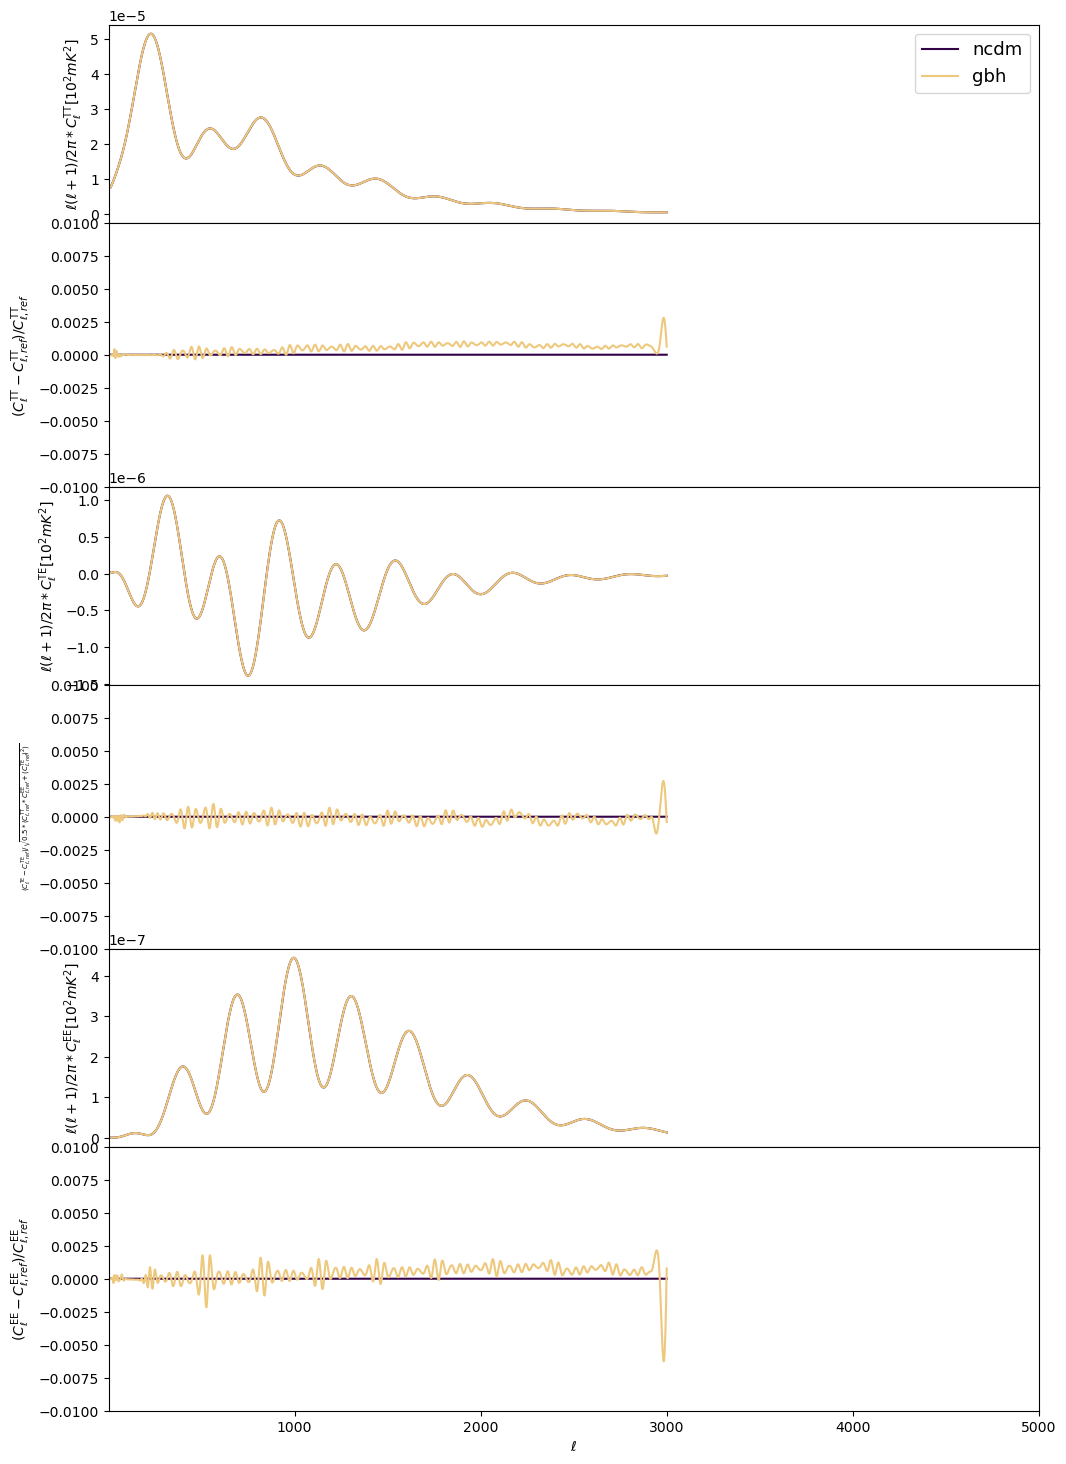

In [ ]:
plot_cl_and_fractional_residuals_no_norm_TTTEEE([ncdm, gbh], ncdm, ['ncdm','gbh'], Planck = False, y_residual_max=0.01)

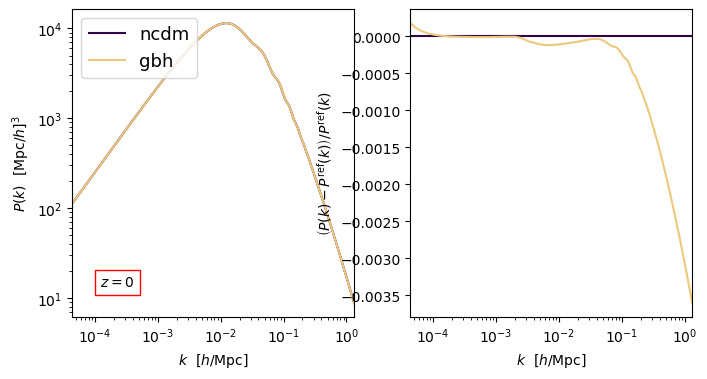

In [ ]:
plot_pk_and_fractional_residuals_no_norm([ncdm, gbh], ncdm, ['ncdm','gbh'])